### Importing Libraries

In [54]:
!pip install --upgrade statsmodels scipy
!pip install "scipy<1.13.0"

  error: subprocess-exited-with-error
  
  Preparing metadata (pyproject.toml) did not run successfully.
  exit code: 1
  
  [22 lines of output]
  + meson setup C:\Users\Dell\AppData\Local\Temp\pip-install-yt1ww9wc\scipy_2a3d8e6209ac4eb19f6c13adee87f9b3 C:\Users\Dell\AppData\Local\Temp\pip-install-yt1ww9wc\scipy_2a3d8e6209ac4eb19f6c13adee87f9b3\.mesonpy-tsd0zhop -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\Dell\AppData\Local\Temp\pip-install-yt1ww9wc\scipy_2a3d8e6209ac4eb19f6c13adee87f9b3\.mesonpy-tsd0zhop\meson-python-native-file.ini
  The Meson build system
  Version: 1.10.2
  Source dir: C:\Users\Dell\AppData\Local\Temp\pip-install-yt1ww9wc\scipy_2a3d8e6209ac4eb19f6c13adee87f9b3
  Build dir: C:\Users\Dell\AppData\Local\Temp\pip-install-yt1ww9wc\scipy_2a3d8e6209ac4eb19f6c13adee87f9b3\.mesonpy-tsd0zhop
  Build type: native build
  Project name: scipy
  Project version: 1.12.0
  C compiler for the host machine: gcc (gcc 6.3.0 "gcc (MinGW.org GCC-6.3.0-


  Using cached scipy-1.12.0.tar.gz (56.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


In [55]:
pip install --upgrade matplotlib seaborn statsmodels

In [56]:
import pandas as pd
import numpy as np
import pylab as py
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats as stat
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.regressionplots import influence_plot

import warnings
warnings.filterwarnings('ignore')

### Importing Dataset

In [58]:
raw_data = pd.read_csv("ToyotaCorolla.csv", encoding='latin1')
raw_data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


### Data Understanding

In [59]:
print('Number of Rows and Columns {}'.format(raw_data.shape))

Number of Rows and Columns (1436, 11)


In [60]:
raw_data.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='str')

In [61]:
raw_data = raw_data[["Price","Age_08_04","KM","HP","cc","Doors","Gears","Weight"]]
raw_data

,Price,Age_08_04,KM,HP,cc,Doors,Gears,Weight
0,13500,23,46986,90,2000,3,5,1165
1,13750,23,72937,90,2000,3,5,1165
2,13950,24,41711,90,2000,3,5,1165
3,14950,26,48000,90,2000,3,5,1165
4,13750,30,38500,90,2000,3,5,1170
...,...,...,...,...,...,...,...,...
1431,7500,69,20544,86,1300,3,5,1025
1432,10845,72,19000,86,1300,3,5,1015
1433,8500,71,17016,86,1300,3,5,1015
1434,7250,70,16916,86,1300,3,5,1015


### Descriptive Analysis

In [62]:
raw_data.describe()

,Price,Age_08_04,KM,HP,cc,Doors,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,1576.85585,4.033426,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,424.38677,0.952677,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,1300.00000,2.000000,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,1400.00000,3.000000,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,1600.00000,4.000000,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,1600.00000,5.000000,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,16000.00000,5.000000,6.000000,1615.00000


### Checking for Data types

In [63]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Price      1436 non-null   int64
 1   Age_08_04  1436 non-null   int64
 2   KM         1436 non-null   int64
 3   HP         1436 non-null   int64
 4   cc         1436 non-null   int64
 5   Doors      1436 non-null   int64
 6   Gears      1436 non-null   int64
 7   Weight     1436 non-null   int64
dtypes: int64(8)
memory usage: 89.9 KB


#### Observation: all the data types are correct .
### Renaming the columns name and making it short

In [64]:
toyota_corolla = raw_data.rename({'Age_08_04':'Age','cc':'CC'},axis=1)
toyota_corolla.head()

,Price,Age,KM,HP,CC,Doors,Gears,Weight
0,13500,23,46986,90,2000,3,5,1165
1,13750,23,72937,90,2000,3,5,1165
2,13950,24,41711,90,2000,3,5,1165
3,14950,26,48000,90,2000,3,5,1165
4,13750,30,38500,90,2000,3,5,1170


### Checking for missing values

In [65]:
toyota_corolla.isnull().sum()

Price     0
Age       0
KM        0
HP        0
CC        0
Doors     0
Gears     0
Weight    0
dtype: int64

### Checking for Duplicated Values


In [66]:
toyota_corolla[toyota_corolla.duplicated()].shape

(1, 8)

In [67]:
toyota_corolla[toyota_corolla.duplicated()]

,Price,Age,KM,HP,CC,Doors,Gears,Weight
113,24950,8,13253,116,2000,5,5,1320


In [68]:
toyota_corolla = toyota_corolla.drop_duplicates().reset_index(drop=True)
toyota_corolla[toyota_corolla.duplicated()]

,Price,Age,KM,HP,CC,Doors,Gears,Weight


#### Observation: There are duplicated values in the dataset Hence, we dropped those values

### Let's find how many discrete and continuous feature are their in our dataset by seperating them in variables

In [69]:
discrete_feature = [feature for feature in toyota_corolla.columns if len(toyota_corolla[feature].unique())<20 and feature]
print('Discrete Variables Count: {}'.format(len(discrete_feature)))

Discrete Variables Count: 4


In [70]:
continuous_feature = [feature for feature in toyota_corolla.columns if toyota_corolla[feature].dtype!='O' and feature not in discrete_feature]
print('Continuous Feature Count {}'.format(len(continuous_feature)))

Continuous Feature Count 4


### Exploratory Data Anlaysis
### Visualizing the Distribution of Continuous Features with the help of Histograms and Probability Plot

In [71]:
import pylab
def plot_data(data,feature):
    plt.figure(figsize=(9,5))
    plt.subplot(1,2,1)
    data[feature].hist()
    plt.subplot(1,2,2)
    stat.probplot(data[feature],dist='norm', plot=pylab)

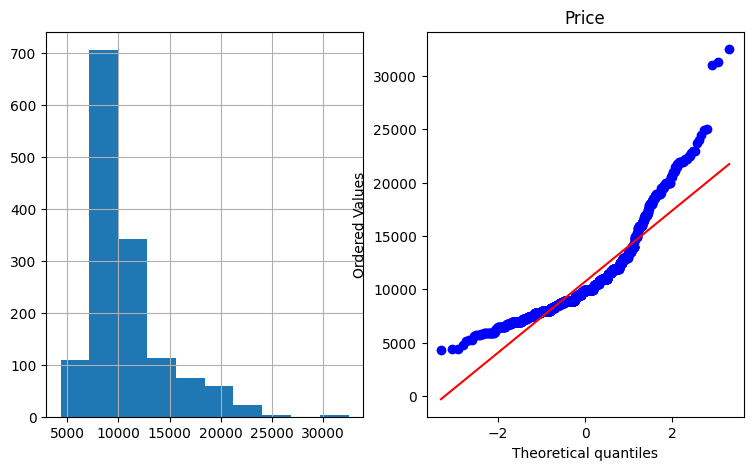

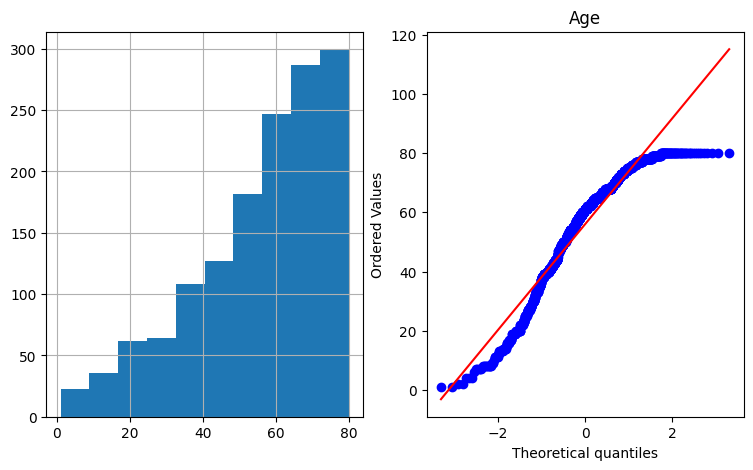

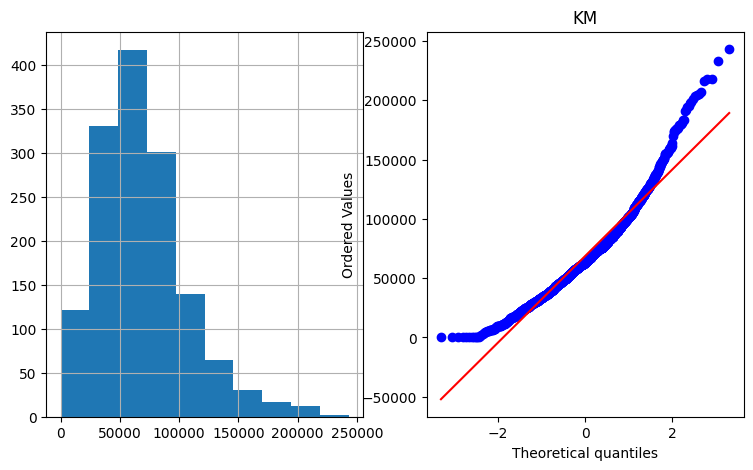

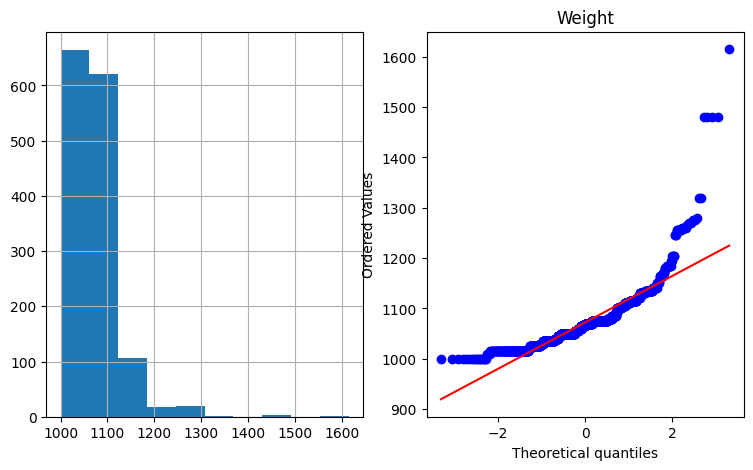

In [72]:
plot_data(toyota_corolla,'Price')
plt.title('Price')
plot_data(toyota_corolla,'Age')
plt.title('Age')
plot_data(toyota_corolla,'KM')
plt.title('KM')
plot_data(toyota_corolla,'Weight')
plt.title('Weight')
plt.show()

### Log transformation and visualizing the Histogram to determine any possible changes in distribution

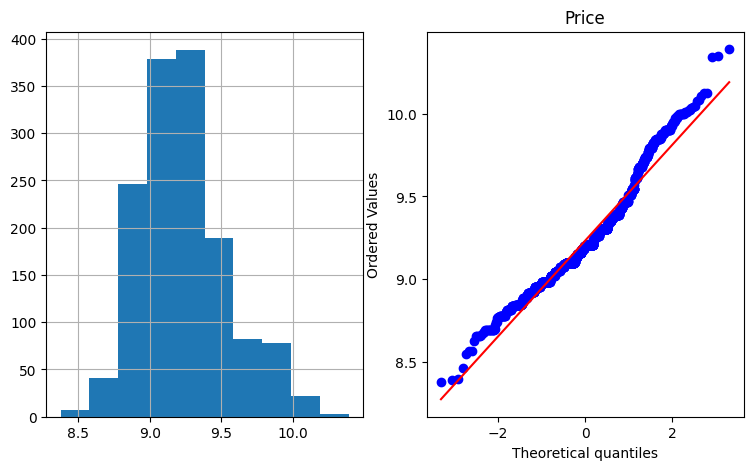

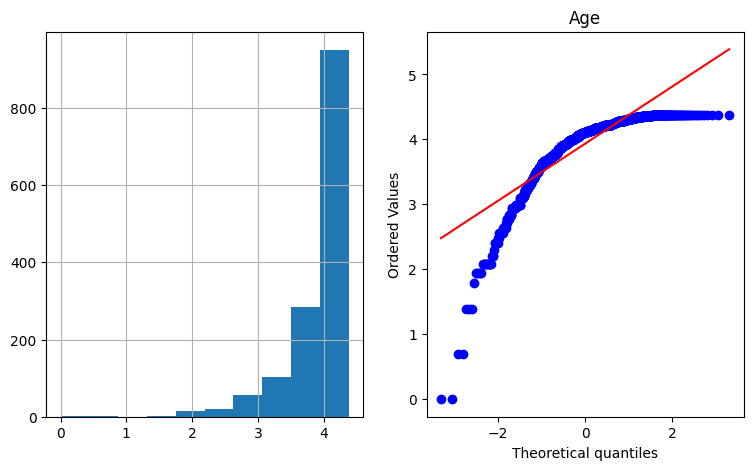

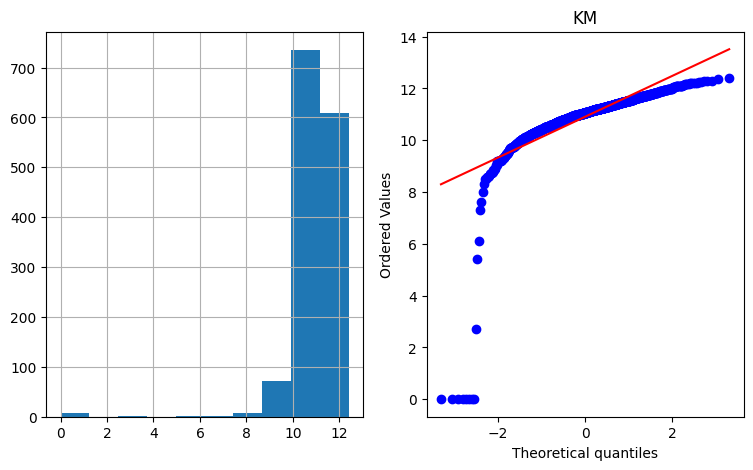

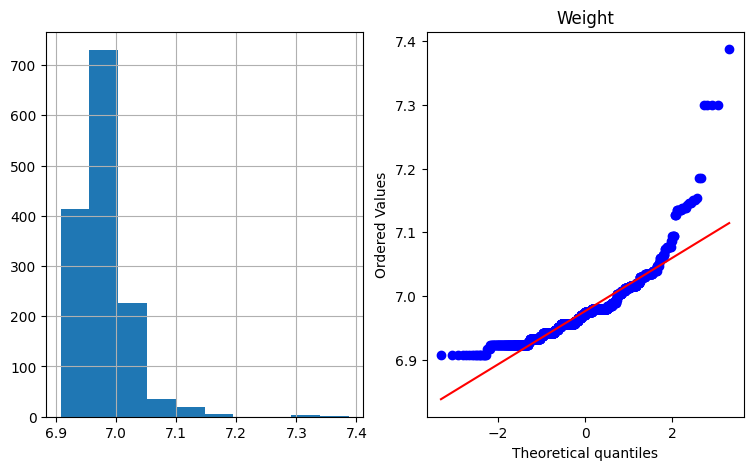

In [73]:
toyota_corolla1 = toyota_corolla.copy()
toyota_corolla1[continuous_feature] = np.log(toyota_corolla1[continuous_feature])

plot_data(toyota_corolla1,'Price')
plt.title('Price')
plot_data(toyota_corolla1,'Age')
plt.title('Age')
plot_data(toyota_corolla1,'KM')
plt.title('KM')
plot_data(toyota_corolla1,'Weight')
plt.title('Weight')
plt.show()

### Square root transformation and visualizing the Histogram to determine any possible changes in distribution

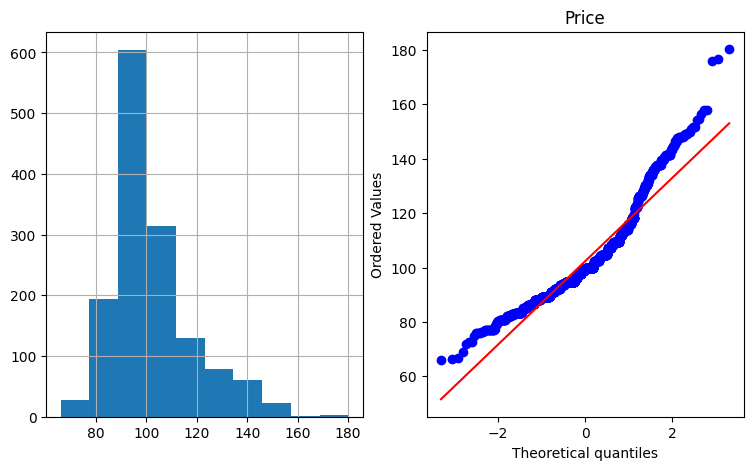

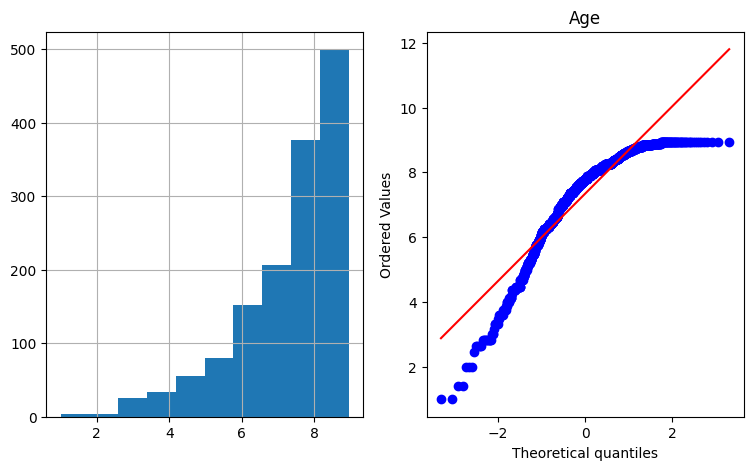

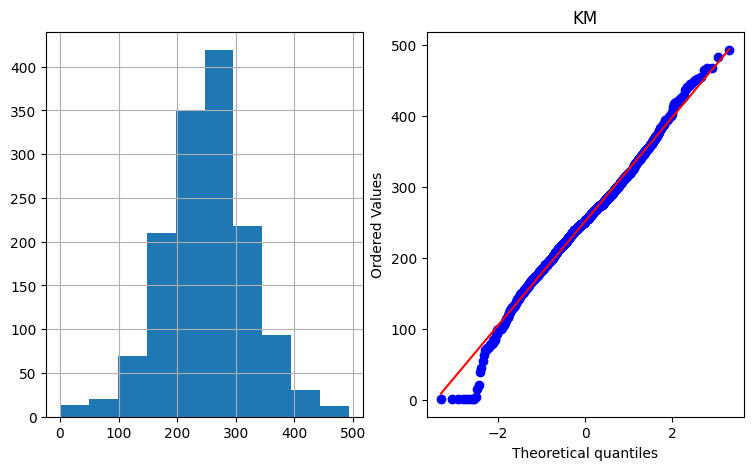

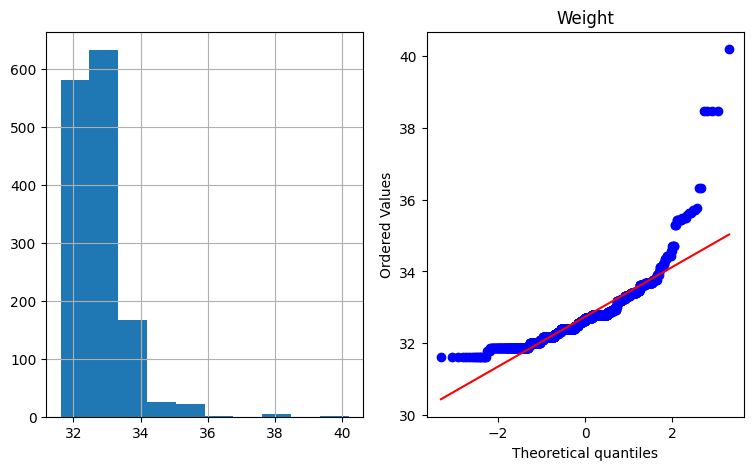

In [74]:
toyota_corolla2 = toyota_corolla.copy()
toyota_corolla2[continuous_feature] = np.sqrt(toyota_corolla2[continuous_feature])

plot_data(toyota_corolla2,'Price')
plt.title('Price')
plot_data(toyota_corolla2,'Age')
plt.title('Age')
plot_data(toyota_corolla2,'KM')
plt.title('KM')
plot_data(toyota_corolla2,'Weight')
plt.title('Weight')
plt.show()

### Cuberoot transformation and visualizing the Histogram to determine any possible changes in distribution

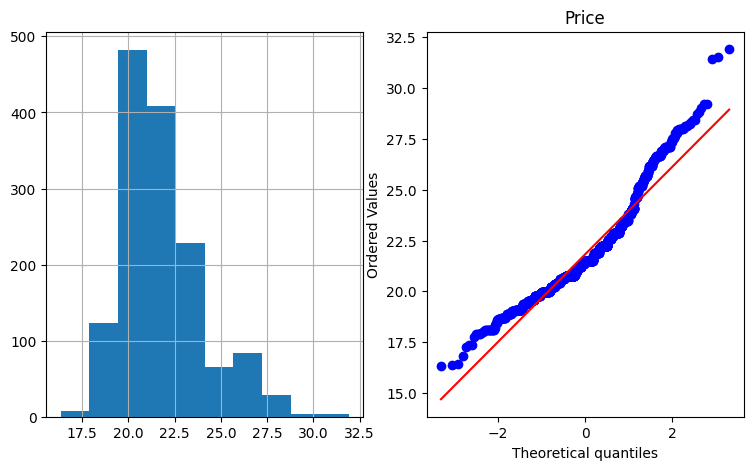

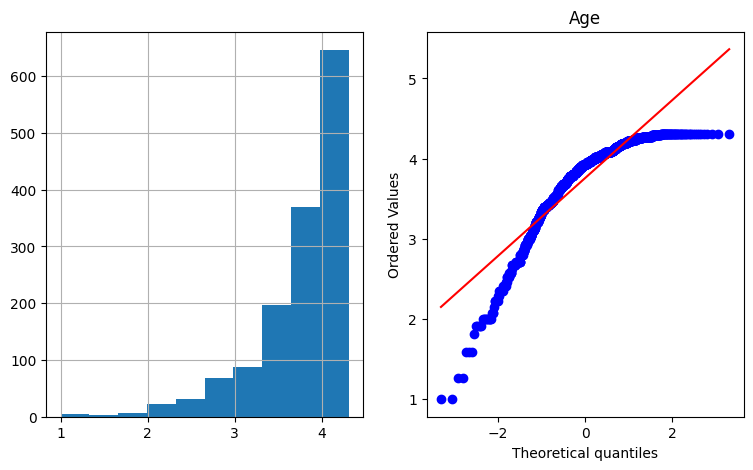

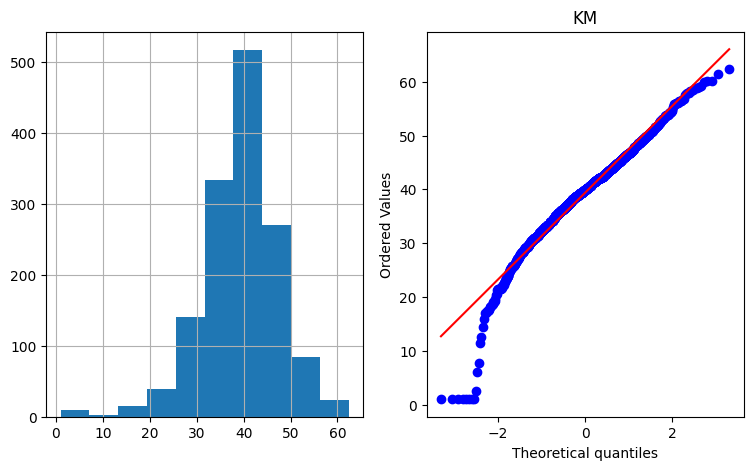

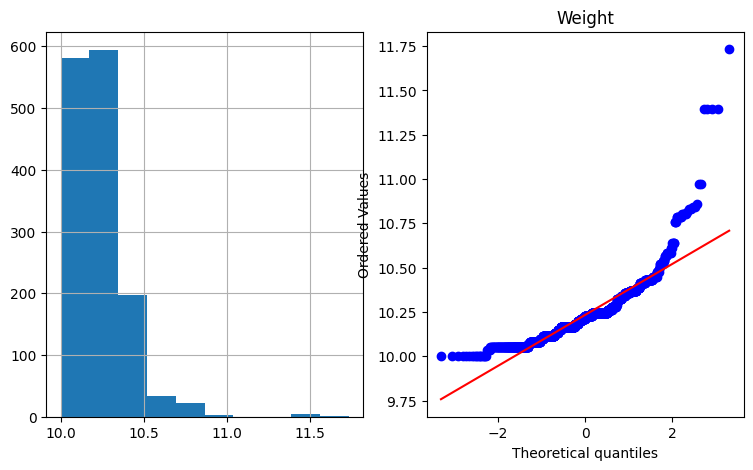

In [75]:
toyota_corolla3 = toyota_corolla.copy()
toyota_corolla3[continuous_feature] = np.cbrt(toyota_corolla3[continuous_feature])

plot_data(toyota_corolla3,'Price')
plt.title('Price')
plot_data(toyota_corolla3,'Age')
plt.title('Age')
plot_data(toyota_corolla3,'KM')
plt.title('KM')
plot_data(toyota_corolla3,'Weight')
plt.title('Weight')
plt.show()

Note: Most of the Continuous Features visually do not look normally distributed lets have some Hypothetical test to check the normailty.

### The Shapiro-Wilk test is a test of normality. It is used to determine whether or not a sample comes from a normal distribution.

In [76]:
toyota_corolla.columns

Index(['Price', 'Age', 'KM', 'HP', 'CC', 'Doors', 'Gears', 'Weight'], dtype='str')

### Perform Shapiro-Wilk test

In [77]:
from scipy.stats import shapiro

print('Price feature  :',shapiro(toyota_corolla.Price),'\n'
      'Age feature    :',shapiro(toyota_corolla.Age),'\n'
      'Weight feature :',shapiro(toyota_corolla.Weight),'\n'
      'KM feature     :',shapiro(toyota_corolla.KM))

Price feature  : ShapiroResult(statistic=np.float64(0.8534721682412996), pvalue=np.float64(1.5957787827354626e-34)) 
Age feature    : ShapiroResult(statistic=np.float64(0.926695692395398), pvalue=np.float64(6.739968150628118e-26)) 
Weight feature : ShapiroResult(statistic=np.float64(0.7825540643634167), pvalue=np.float64(5.04273837821291e-40)) 
KM feature     : ShapiroResult(statistic=np.float64(0.947581681921263), pvalue=np.float64(3.4417651852891926e-22))


#### Observation: Since the p-values are less than .05, we reject the null hypothesis.
* We have sufficient evidence to say that the sample data does not come from a normal distribution.

### Visualizing the Relation between each independent Feature with respect to the Dependent Feature

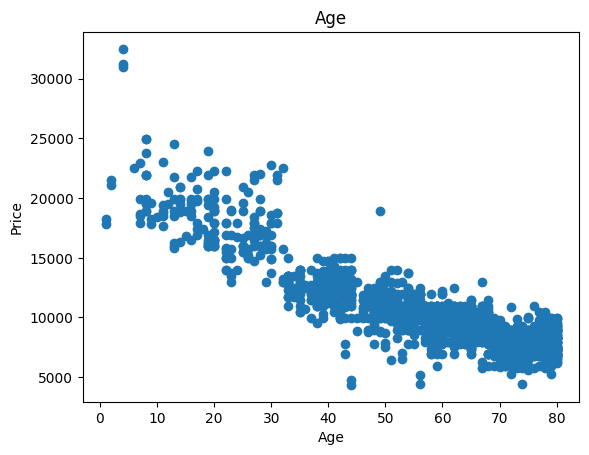

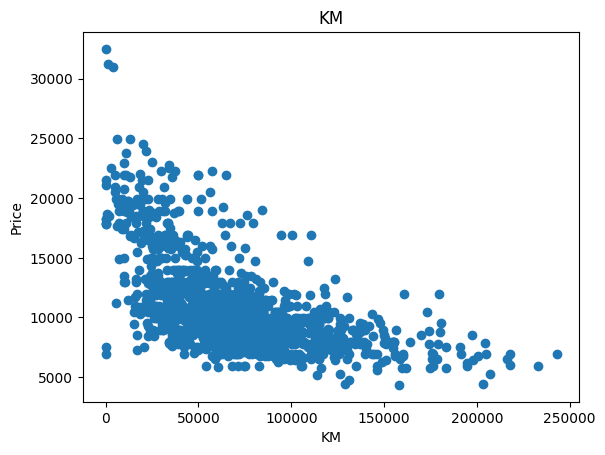

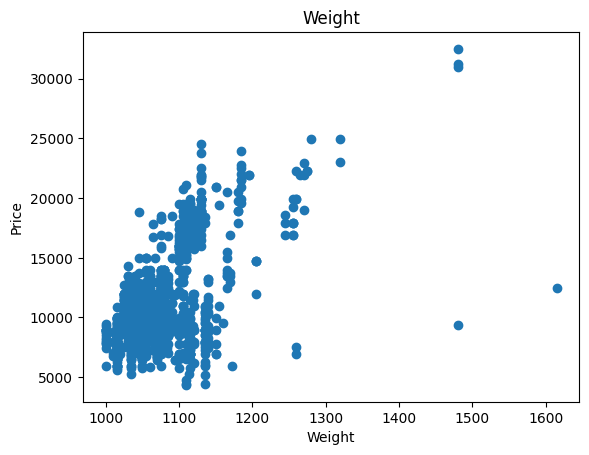

In [78]:
for feature in continuous_feature:
    if feature!="Price":
        df = toyota_corolla.copy()         
        plt.scatter(df[feature],df['Price'])
        plt.xlabel(feature)
        plt.ylabel('Price')
        plt.title(feature)
        plt.show()

#### Observation: Age feature has a good linear relation with Price a Negative Correlation as compare to other features
### Lets analyze the relationship between the discrete variables and Price

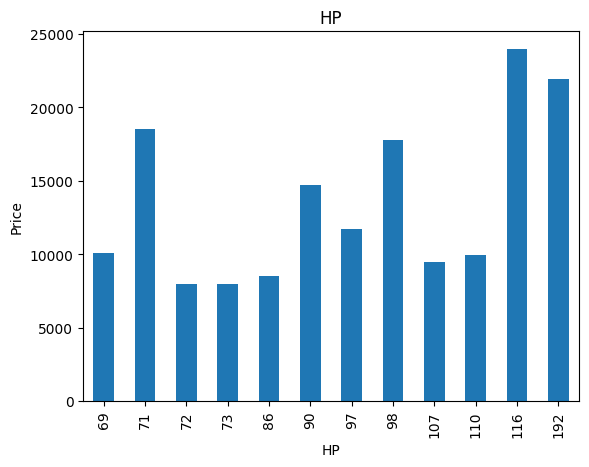

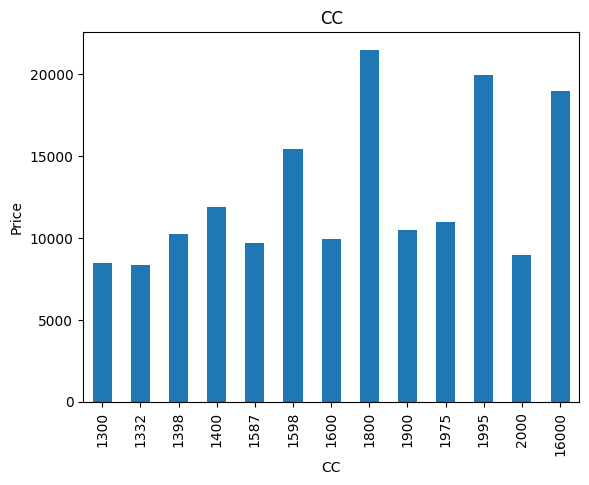

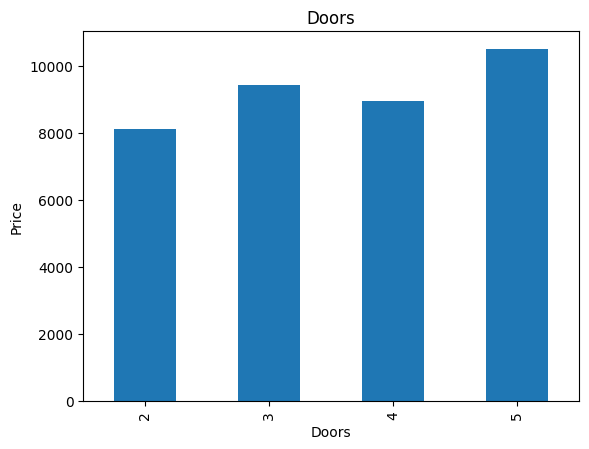

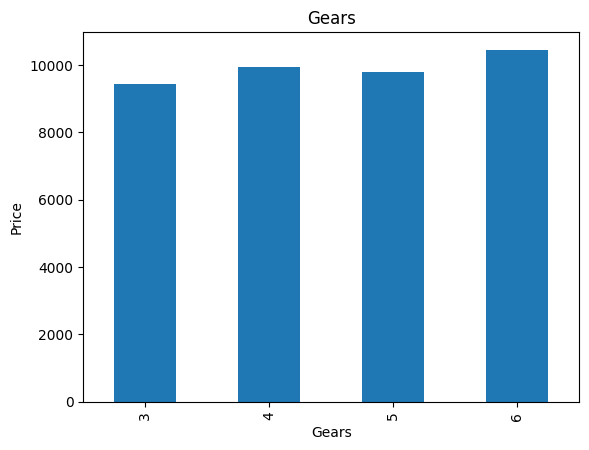

In [79]:
for feature in discrete_feature:
    toyota_corolla = toyota_corolla.copy()
    toyota_corolla.groupby(feature)["Price"].median().plot.bar()
    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.title(feature)
    plt.show()

#### Observation:There is'nt much of difference between how much Gears and Doors each Car has to have a sginificant amount of changes in Prices from each other and there is'nt any direct relation
### Visualizing Continuous Datatype for Outlier Detection

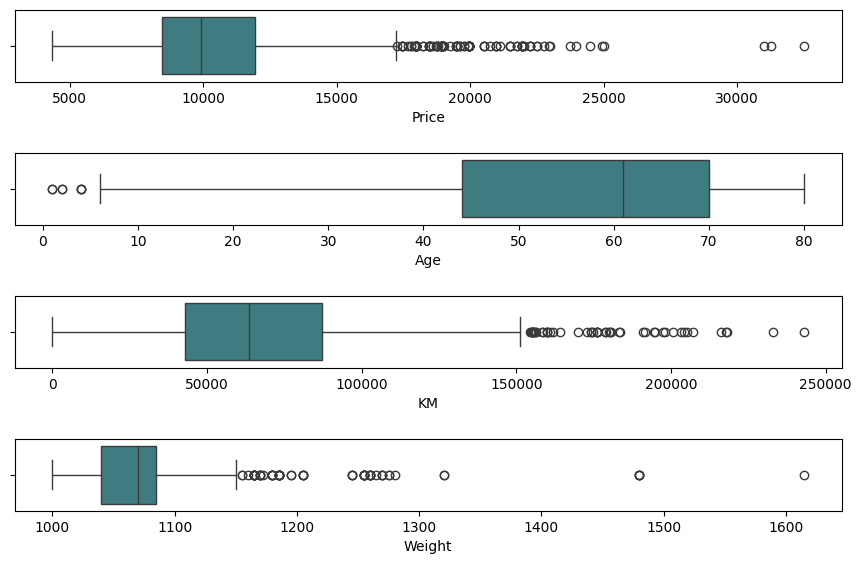

In [80]:
toyota_corolla = toyota_corolla.copy() 
fig, axes=plt.subplots(4,1,figsize=(9,6),sharex=False,sharey=False)
sns.boxplot(x='Price',data=toyota_corolla,palette='crest',ax=axes[0])
sns.boxplot(x='Age',data=toyota_corolla,palette='crest',ax=axes[1])
sns.boxplot(x='KM',data=toyota_corolla,palette='crest',ax=axes[2])
sns.boxplot(x='Weight',data=toyota_corolla,palette='crest',ax=axes[3])
plt.tight_layout(pad=2.0)

#### Observation: A significant amount of outliers are present in each continuous feature
**Note:**

* We can't simply remove the outliers that would mean loss of information
* We need to try different types of transformation or imputation and select the one with the best results
* Note: Transforming variables can also eliminate outliers. The Transformed Variables reduces the variation caused by thr extreme values

**Before handling Outliers lets build a model and compare its R-squared value with other techniques to see which technique suits best for out case**

### Let's try Median Imputation to handle Outlier in Profit

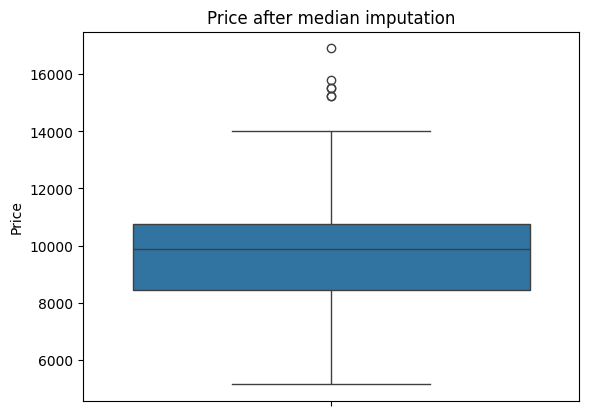

In [81]:
toyota_corolla4 = toyota_corolla.copy()
for i in toyota_corolla['Price']:
    q1 = np.quantile(toyota_corolla4.Price,0.25)
    q3 = np.quantile(toyota_corolla4.Price,0.75)
    med = np.median(toyota_corolla4.Price)
    iqr = q3 - q1
    upper_bound = q3+(1.5*iqr)
    lower_bound = q1-(1.5*iqr)
    if i > upper_bound or i < lower_bound:
        toyota_corolla4['Price'] = toyota_corolla4['Price'].replace(i, np.median(toyota_corolla4['Price']))
sns.boxplot(toyota_corolla4['Price'])
plt.title('Price after median imputation')
plt.show()

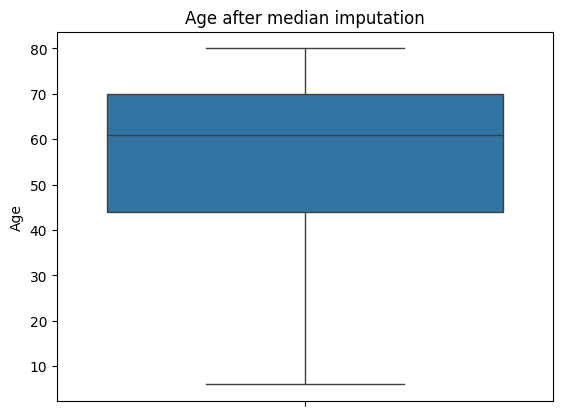

In [82]:
for i in toyota_corolla['Age']:
    q1 = np.quantile(toyota_corolla4.Age,0.25)
    q3 = np.quantile(toyota_corolla4.Age,0.75)
    med = np.median(toyota_corolla4.Age)
    iqr = q3 - q1
    upper_bound = q3+(1.5*iqr)
    lower_bound = q1-(1.5*iqr)
    if i > upper_bound or i < lower_bound:
        toyota_corolla4['Age'] = toyota_corolla4['Age'].replace(i, np.median(toyota_corolla4['Age']))
sns.boxplot(toyota_corolla4['Age'])
plt.title('Age after median imputation')
plt.show()

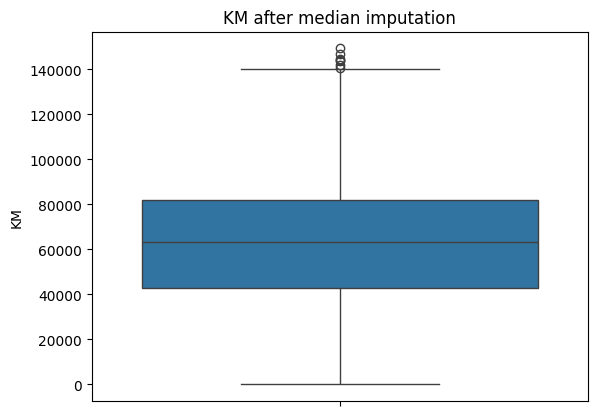

In [83]:
for i in toyota_corolla['KM']:
    q1 = np.quantile(toyota_corolla4.KM,0.25)
    q3 = np.quantile(toyota_corolla4.KM,0.75)
    med = np.median(toyota_corolla4.KM)
    iqr = q3 - q1
    upper_bound = q3+(1.5*iqr)
    lower_bound = q1-(1.5*iqr)
    if i > upper_bound or i < lower_bound:
        toyota_corolla4['KM'] = toyota_corolla4['KM'].replace(i, np.median(toyota_corolla4['KM']))
sns.boxplot(toyota_corolla4['KM'])
plt.title('KM after median imputation')
plt.show()

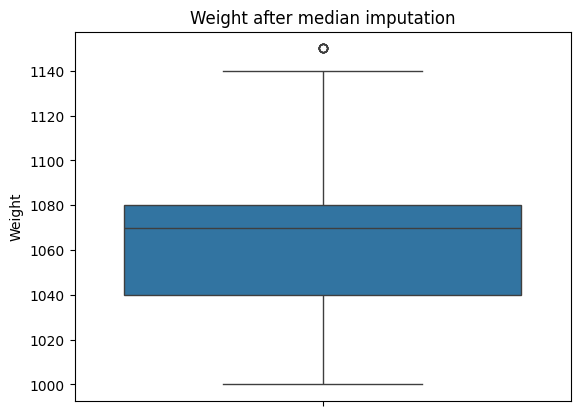

In [84]:
for i in toyota_corolla['Weight']:
    q1 = np.quantile(toyota_corolla4.Weight,0.25)
    q3 = np.quantile(toyota_corolla.Weight,0.75)
    med = np.median(toyota_corolla4.Weight)
    iqr = q3 - q1
    upper_bound = q3+(1.5*iqr)
    lower_bound = q1-(1.5*iqr)
    if i > upper_bound or i < lower_bound:
        toyota_corolla4['Weight'] = toyota_corolla4['Weight'].replace(i, np.median(toyota_corolla4['Weight']))
sns.boxplot(toyota_corolla4['Weight'])
plt.title('Weight after median imputation')
plt.show()

### Let's test our data in model and find the R-squared with median imputation data model

In [85]:
median_imputation_model = smf.ols("Price ~ Age + KM + Weight", data = toyota_corolla4).fit()
# Finding rsquared values
print('R-squared     :',median_imputation_model.rsquared.round(3))
print('Adj.R-squared :',median_imputation_model.rsquared_adj.round(3))

R-squared     : 0.343
Adj.R-squared : 0.341


#### Observation: As you can see after median imputation the model is not performing well

* Now we have to try something else to get out better results than the raw data

### Let's try Mean Imputation to handle Outlier in Profit

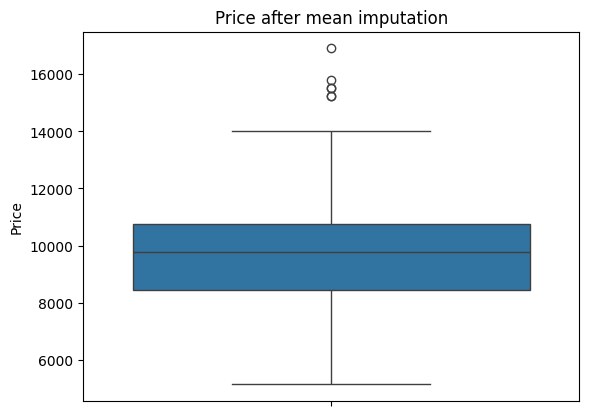

In [86]:
toyota_corolla5 = toyota_corolla.copy()
for i in toyota_corolla['Price']:
    q1 = np.quantile(toyota_corolla5.Price,0.25)
    q3 = np.quantile(toyota_corolla5.Price,0.75)
    med = np.median(toyota_corolla5.Price)
    iqr = q3 - q1
    upper_bound = q3+(1.5*iqr)
    lower_bound = q1-(1.5*iqr)
    if i > upper_bound or i < lower_bound:
        toyota_corolla5['Price'] = toyota_corolla5['Price'].replace(i, np.mean(toyota_corolla5['Price']))
sns.boxplot(toyota_corolla5['Price'])
plt.title('Price after mean imputation')
plt.show()

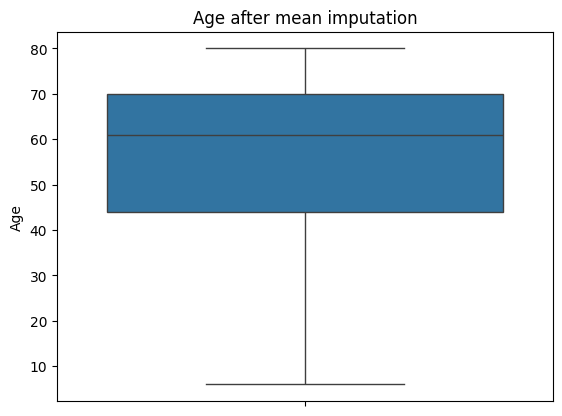

In [87]:
for i in toyota_corolla['Age']:
    q1 = np.quantile(toyota_corolla5.Age,0.25)
    q3 = np.quantile(toyota_corolla5.Age,0.75)
    med = np.median(toyota_corolla5.Age)
    iqr = q3 - q1
    upper_bound = q3+(1.5*iqr)
    lower_bound = q1-(1.5*iqr)
    if i > upper_bound or i < lower_bound:
        toyota_corolla5['Age'] = toyota_corolla5['Age'].replace(i, np.mean(toyota_corolla5['Age']))
sns.boxplot(toyota_corolla5['Age'])
plt.title('Age after mean imputation')
plt.show()

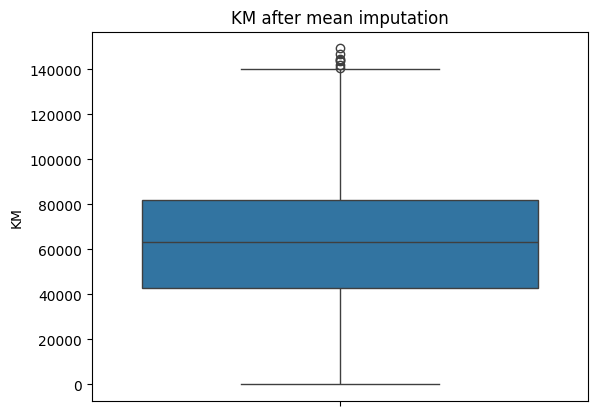

In [88]:
for i in toyota_corolla['KM']:
    q1 = np.quantile(toyota_corolla5.KM,0.25)
    q3 = np.quantile(toyota_corolla5.KM,0.75)
    med = np.median(toyota_corolla5.KM)
    iqr = q3 - q1
    upper_bound = q3+(1.5*iqr)
    lower_bound = q1-(1.5*iqr)
    if i > upper_bound or i < lower_bound:
        toyota_corolla5['KM'] = toyota_corolla5['KM'].replace(i, np.mean(toyota_corolla5['KM']))
sns.boxplot(toyota_corolla5['KM'])
plt.title('KM after mean imputation')
plt.show()

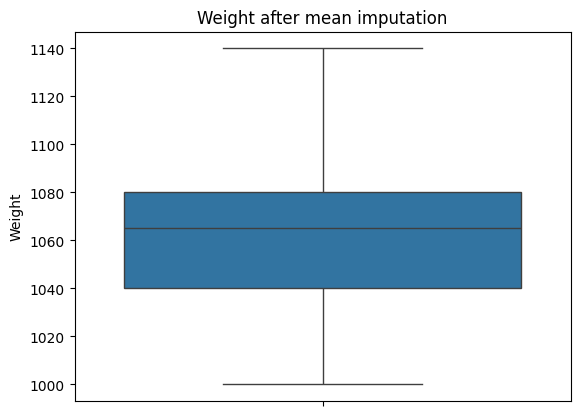

In [89]:
for i in toyota_corolla['Weight']:
    q1 = np.quantile(toyota_corolla5.Weight,0.25)
    q3 = np.quantile(toyota_corolla5.Weight,0.75)
    med = np.median(toyota_corolla5.Weight)
    iqr = q3 - q1
    upper_bound = q3+(1.5*iqr)
    lower_bound = q1-(1.5*iqr)
    if i > upper_bound or i < lower_bound:
        toyota_corolla5['Weight'] = toyota_corolla5['Weight'].replace(i, np.mean(toyota_corolla5['Weight']))
sns.boxplot(toyota_corolla5['Weight'])
plt.title('Weight after mean imputation')
plt.show()

### Let's test our data in model and find the R-squared with mean imputation data model

In [90]:
mean_imputation_model = smf.ols("Price ~ Age + KM + Weight", data = toyota_corolla5).fit()
# Finding rsquared values
print('R-squared     :',mean_imputation_model.rsquared.round(3))
print('Adj.R-squared :',mean_imputation_model.rsquared_adj.round(3))

R-squared     : 0.388
Adj.R-squared : 0.387


#### Observation: As you can see even after mean imputation the model is not performing well it getting worse

* Now we have to try something else to get out model better than the raw data

### The best thing we can do is now to remove the outlier and see the results

In [91]:
toyota_corolla6 = toyota_corolla.copy()
def drop_outliers(data, field_name):
    iqr = 1.5*(np.percentile(data[field_name], 75) - np.percentile(data[field_name], 25))
    data.drop(data[data[field_name] > (iqr + np.percentile(data[field_name], 75))].index, inplace=True)
    data.drop(data[data[field_name] < (np.percentile(data[field_name], 25) - iqr)].index, inplace=True)

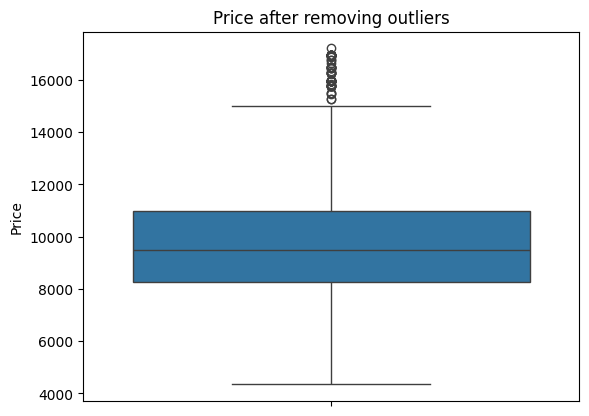

In [92]:
drop_outliers(toyota_corolla6, 'Price')
sns.boxplot(toyota_corolla6.Price)
plt.title('Price after removing outliers')
plt.show()

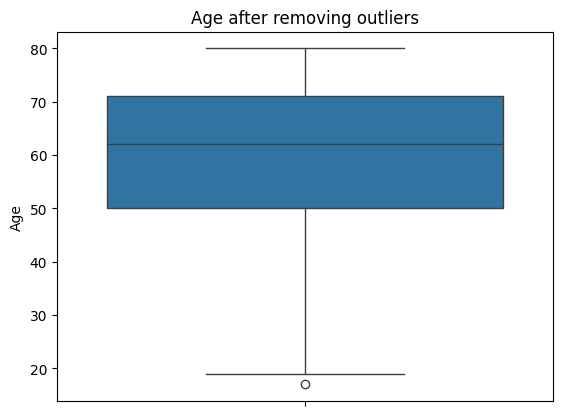

In [93]:
drop_outliers(toyota_corolla6, 'Age')
sns.boxplot(toyota_corolla6.Age)
plt.title('Age after removing outliers')
plt.show()

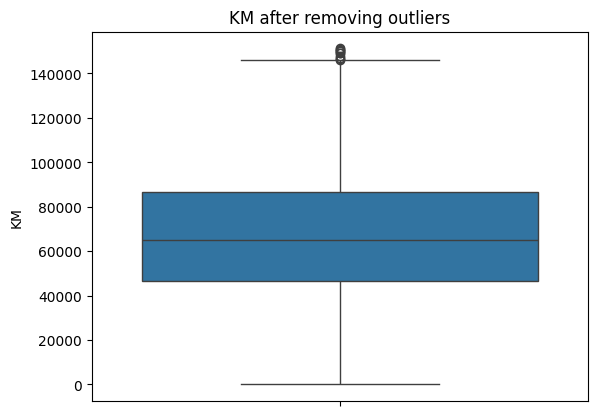

In [94]:
drop_outliers(toyota_corolla6, 'KM')
sns.boxplot(toyota_corolla6.KM)
plt.title('KM after removing outliers')
plt.show()

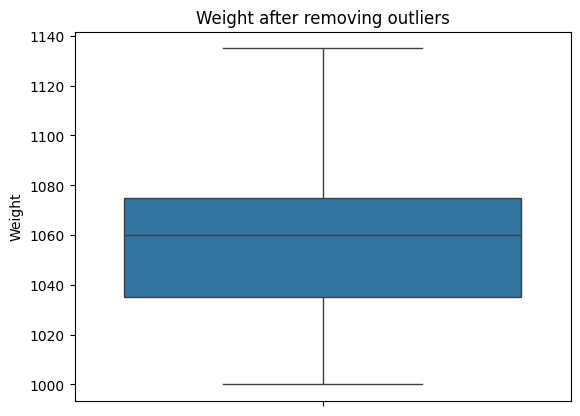

In [95]:
drop_outliers(toyota_corolla6, 'Weight')
sns.boxplot(toyota_corolla6.Weight)
plt.title('Weight after removing outliers')
plt.show()

### Let's test our data in model and compare the R-squared with without imputation data model

In [96]:
removed_outlier_model = smf.ols("Price ~ Age + KM + Weight", data = toyota_corolla6).fit()
# Finding rsquared values
print('R-squared     :',removed_outlier_model.rsquared.round(3))
print('Adj.R-squared :',removed_outlier_model.rsquared_adj.round(3))

R-squared     : 0.778
Adj.R-squared : 0.777


In [97]:
np.sqrt(removed_outlier_model.mse_resid)

np.float64(1060.0301342603996)

### Let's try log transformation and visualize the result first

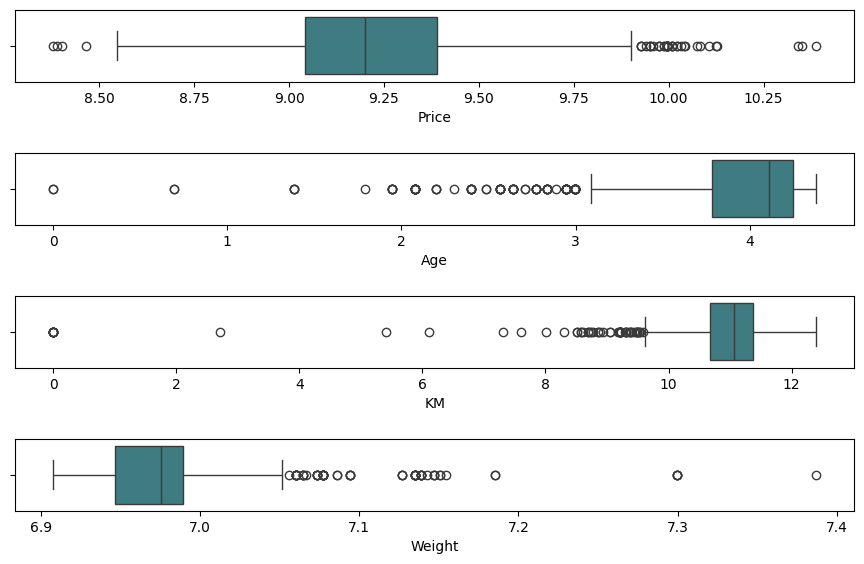

In [98]:
toyota_corolla7 = toyota_corolla.copy()
toyota_corolla7[continuous_feature]=np.log(toyota_corolla7[continuous_feature])
    
fig, axes=plt.subplots(4,1,figsize=(9,6),sharex=False,sharey=False)
sns.boxplot(x='Price',data=toyota_corolla7,palette='crest',ax=axes[0])
sns.boxplot(x='Age',data=toyota_corolla7,palette='crest',ax=axes[1])
sns.boxplot(x='KM',data=toyota_corolla7,palette='crest',ax=axes[2])
sns.boxplot(x='Weight',data=toyota_corolla7,palette='crest',ax=axes[3])
plt.tight_layout(pad=2.0)

In [99]:
log_transfomed = toyota_corolla.copy()
log_transfomed[continuous_feature] = np.log(log_transfomed[continuous_feature])
log_transformed_model = smf.ols("Price ~ Age + KM + Weight", data = log_transfomed).fit()
# Finding rsquared values
print('R-squared     :',log_transformed_model.rsquared.round(3))
print('Adj.R-squared :',log_transformed_model.rsquared_adj.round(3))

R-squared     : 0.707
Adj.R-squared : 0.706


#### Observation: The outliers are still present
### Let's try cuberoot transformation and visualize the result first

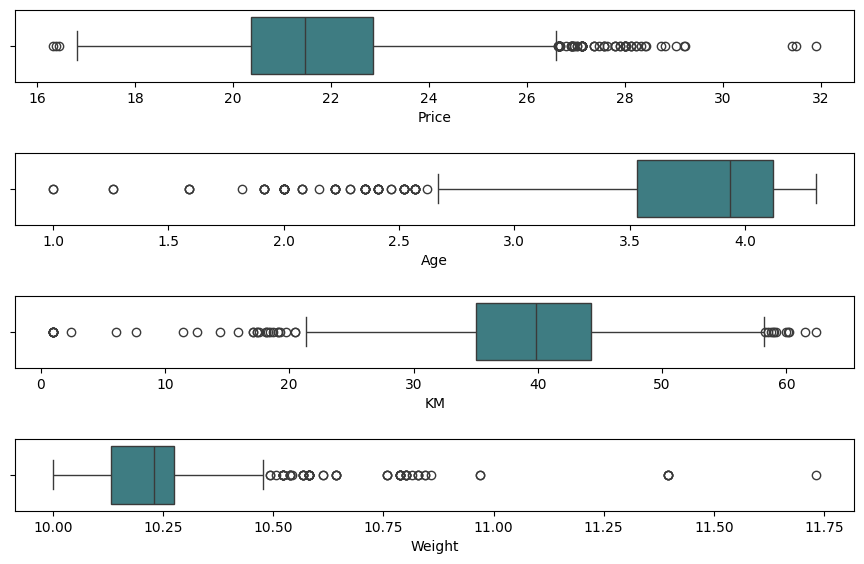

In [100]:
toyota_corolla8 = toyota_corolla.copy()
toyota_corolla8[continuous_feature]=np.cbrt(toyota_corolla8[continuous_feature])

fig, axes=plt.subplots(4,1,figsize=(9,6),sharex=False,sharey=False)
sns.boxplot(x='Price',data=toyota_corolla8,palette='crest',ax=axes[0])
sns.boxplot(x='Age',data=toyota_corolla8,palette='crest',ax=axes[1])
sns.boxplot(x='KM',data=toyota_corolla8,palette='crest',ax=axes[2])
sns.boxplot(x='Weight',data=toyota_corolla8,palette='crest',ax=axes[3])
plt.tight_layout(pad=2.0)

In [45]:
cube_root_transfomed = toyota_corolla.copy()
cube_root_transfomed[continuous_feature]=np.cbrt(cube_root_transfomed[continuous_feature])
cube_root_transformed_model = smf.ols("Price ~ Age + KM + Weight", data = cube_root_transfomed).fit()
# Finding rsquared values
print('R-squared     :',cube_root_transformed_model.rsquared.round(3))
print('Adj.R-squared :',cube_root_transformed_model.rsquared_adj.round(3))

R-squared     : 0.815
Adj.R-squared : 0.814


#### Observation: The outliers are still present
* After removing Outliers the model performed very poorly than the raw data model
* Note: We will continue with different technique to deal with that

### Raw Data Model

In [46]:
toyota_corolla.columns

Index(['Price', 'Age', 'KM', 'HP', 'CC', 'Doors', 'Gears', 'Weight'], dtype='str')

In [101]:
raw_data_model = smf.ols("Price ~ Age + KM + Weight + HP + CC + Gears  + Doors", data = toyota_corolla).fit()
# Finding rsquared values
print('R-squared     :',raw_data_model.rsquared.round(3))
print('Adj.R-squared :',raw_data_model.rsquared_adj.round(3))

R-squared     : 0.862
Adj.R-squared : 0.861


In [102]:
np.sqrt(raw_data_model.mse_resid)

np.float64(1345.4050298691927)

### Model Deletion Diagnostics (checking Outliers or Influencers)
* **Two Techniques : 1. Cook's Distance 2. Leverage value**

#### 1. Cook's Distance: If Cook's distance > 1, then it's an outlier
### Get influencers using cook's distance

In [103]:
influence_points = raw_data_model.get_influence()
c, p_value = influence_points.cooks_distance
c, p_value

(array([4.31448029e-03, 2.47767928e-03, 3.10453539e-03, ...,
        3.52979316e-06, 7.17412605e-04, 1.05021261e-02], shape=(1435,)),
 array([1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        0.99999987], shape=(1435,)))

#### Leverage Value using High Influence Points : Points beyond Leverage_cutoff value are influencers

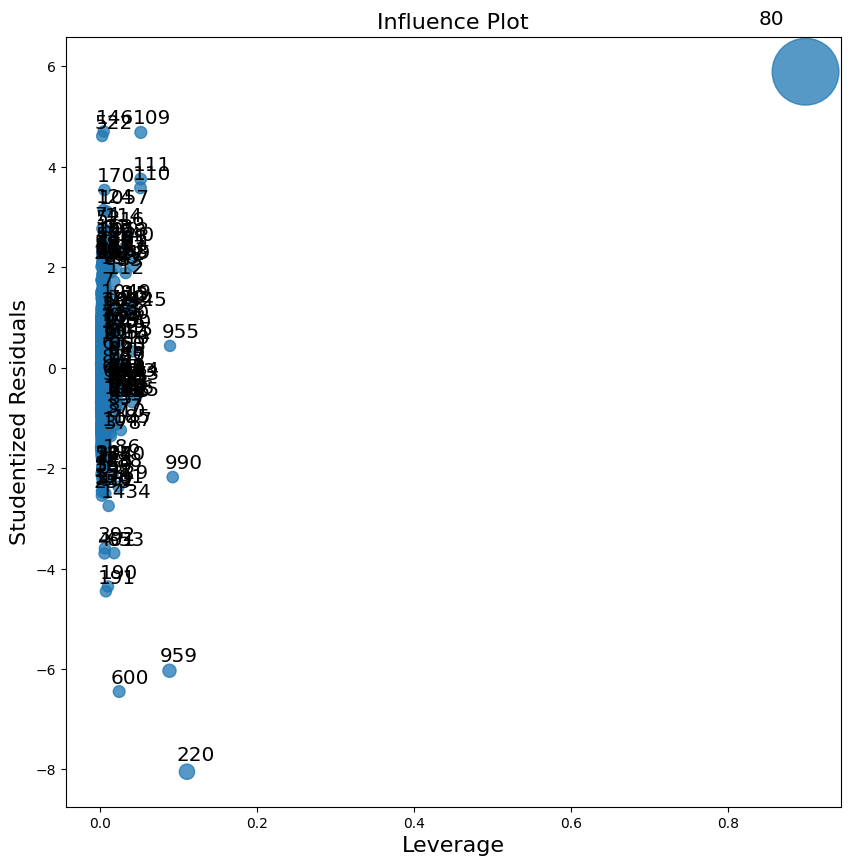

In [104]:
fig,ax = plt.subplots(figsize=(10,10))
fig = influence_plot(raw_data_model,ax = ax)
plt.show()

### Leverage Cuttoff Value = 3*(k+1)/n ; k = no.of features/columns & n = no. of datapoints

In [105]:
k = toyota_corolla.shape[1]
n = toyota_corolla.shape[0]
leverage_cutoff = (3*(k+1))/n
print('Cut-off line at',np.round(leverage_cutoff,3))

Cut-off line at 0.019


### Let's plot the influencers and also plot a cut off line using the stem plot

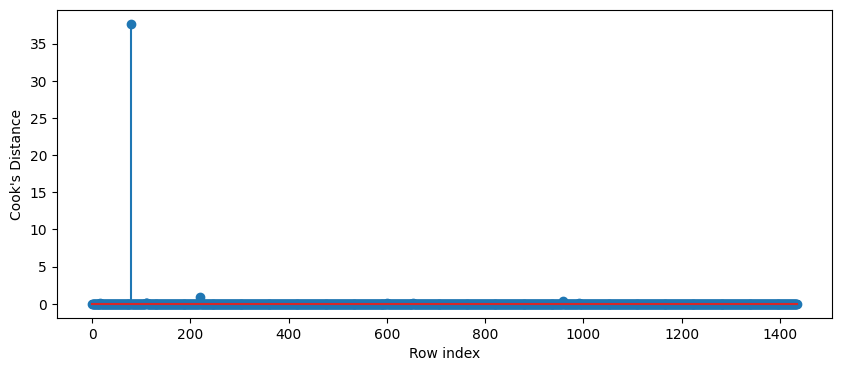

In [106]:
fig = plt.figure(figsize = (10,4))
x = [0,48]
y = [0.1,0.1]
plt.plot(x, y,color='darkred', linewidth=2)
y1 = [0.05,0.05]
plt.plot(x , y1, color = 'red', linewidth = 2)
plt.stem(np.arange(len(toyota_corolla)), np.round(c, 3))
plt.xlabel('Row index')
plt.ylabel("Cook's Distance")
plt.show()

#### Index and value of influencer where C>0.5

In [107]:
np.argmax(c), np.max(c)

(np.int64(80), np.float64(37.679388032631934))

In [108]:
toyota_corolla[toyota_corolla.index.isin([80])] 

,Price,Age,KM,HP,CC,Doors,Gears,Weight
80,18950,25,20019,110,16000,5,5,1180


### Let's improve the model by deleting the influence point and creating a new dataframe
**Discard the data points which are influencers and reassign the row number (reset_index(drop=True))**

In [109]:
dataframe = toyota_corolla.copy()
dataframe = dataframe.drop(dataframe.index[[80]],axis=0).reset_index(drop=True)
dataframe.head()

,Price,Age,KM,HP,CC,Doors,Gears,Weight
0,13500,23,46986,90,2000,3,5,1165
1,13750,23,72937,90,2000,3,5,1165
2,13950,24,41711,90,2000,3,5,1165
3,14950,26,48000,90,2000,3,5,1165
4,13750,30,38500,90,2000,3,5,1170


In [110]:
toyota_corolla.shape

(1435, 8)

In [111]:
dataframe.shape

(1434, 8)

### Model Deletion Diagnostics and Final Model

In [112]:
while raw_data_model.rsquared < 0.90:
    for c in [np.max(c)>leverage_cutoff]:
        raw_data_model=smf.ols('Price~Age+KM+HP+CC+Doors+Gears+Weight',data=dataframe).fit()
        (c,_)=raw_data_model.get_influence().cooks_distance
        c
        np.argmax(c) , np.max(c)
        dataframe=dataframe.drop(dataframe.index[[np.argmax(c)]],axis=0).reset_index(drop=True)
        dataframe
    else:
        final_model=smf.ols('Price~Age+KM+HP+CC+Doors+Gears+Weight',data=dataframe).fit()
        final_model.rsquared , final_model.aic
        print("Thus model accuracy is improved to",final_model.rsquared)

Thus model accuracy is improved to 0.873771382961479
Thus model accuracy is improved to 0.8828097629775793
Thus model accuracy is improved to 0.8876768823747953
Thus model accuracy is improved to 0.8883876203813486
Thus model accuracy is improved to 0.8907513864294684
Thus model accuracy is improved to 0.8881255776595515
Thus model accuracy is improved to 0.889545630443298
Thus model accuracy is improved to 0.8890311439985206
Thus model accuracy is improved to 0.8883748384292552
Thus model accuracy is improved to 0.8878234359820893
Thus model accuracy is improved to 0.8873333727360391
Thus model accuracy is improved to 0.8889613474651937
Thus model accuracy is improved to 0.8898618883756102
Thus model accuracy is improved to 0.8903225592560308
Thus model accuracy is improved to 0.8913962001227943
Thus model accuracy is improved to 0.8919292331578995
Thus model accuracy is improved to 0.8929397686172271
Thus model accuracy is improved to 0.8924090031958348
Thus model accuracy is improve

#### Another Method

In [113]:
k = dataframe.shape[1]
n = dataframe.shape[0]
leverage_cutoff = (3*(k+1))/n
while np.max(c)>leverage_cutoff:
    model = smf.ols('Price ~ Age + KM + HP + CC + Doors + Gears + Weight', data=dataframe).fit()
    (c,_) = model.get_influence().cooks_distance
    c
    np.argmax(c) , np.max(c)
    dataframe = dataframe.drop(dataframe.index[[np.argmax(c)]],axis=0).reset_index(drop=True)
    dataframe
else:
    final_model = smf.ols('Price ~ Age + KM + HP + CC + Doors + Gears  + Weight',data=dataframe).fit()
    final_model.rsquared , final_model.aic
    print("This model accuracy is improved to",final_model.rsquared)

This model accuracy is improved to 0.9006833193175715


In [114]:
influence_points = final_model.get_influence()
c, p_value = influence_points.cooks_distance
c, p_value

(array([1.19933771e-03, 2.71589148e-05, 9.87565801e-04, ...,
        6.67444661e-05, 1.43475713e-03, 9.09031405e-05], shape=(1100,)),
 array([1., 1., 1., ..., 1., 1., 1.], shape=(1100,)))

In [115]:
dataframe.shape

(1100, 8)

In [116]:
dataframe.head()

,Price,Age,KM,HP,CC,Doors,Gears,Weight
0,14950,26,48000,90,2000,3,5,1165
1,16900,27,94612,90,2000,3,5,1245
2,16950,29,43905,110,1600,3,5,1170
3,15950,28,56349,110,1600,3,5,1120
4,16250,29,25813,110,1600,3,5,1120


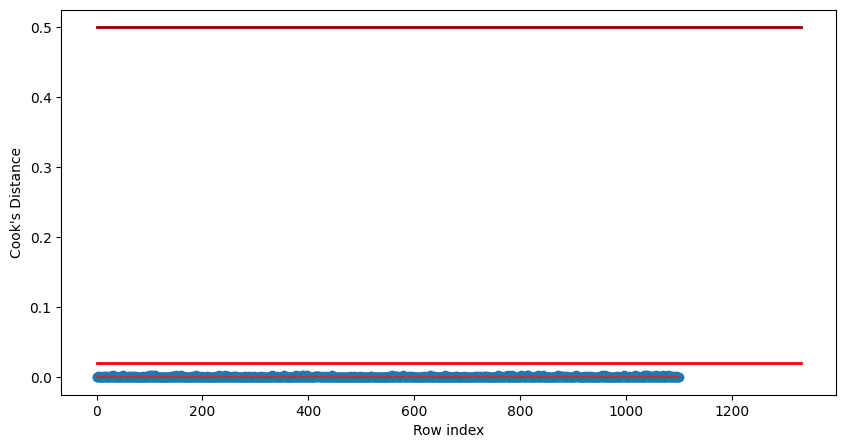

In [117]:
fig = plt.figure(figsize = (10,5))
x = [0,1330]
y = [0.5,0.5]
plt.plot(x, y,color='darkred', linewidth=2)
y1 = [0.02,0.02]
plt.plot(x , y1, color = 'red', linewidth = 2)
plt.stem(np.arange(len(dataframe)), np.round(c, 3))
plt.xlabel('Row index')
plt.ylabel("Cook's Distance")
plt.show()

#### Observation: All the points are below our cut-off line
* Hence, we can say that there are no influncers present in our model we can proceed with the predictions

In [118]:
print('R-squared     :',final_model.rsquared.round(3))
print('Adj.R-squared :',final_model.rsquared_adj.round(3))
print('AIC Value     :',final_model.aic.round(3))
print('BIC Value     :',final_model.bic.round(3))
print('P-Value       :\n',final_model.pvalues)

R-squared     : 0.901
Adj.R-squared : 0.9
AIC Value     : 17669.68
BIC Value     : 17709.705
P-Value       :
 Intercept     2.520976e-16
Age          8.099736e-303
KM            1.652756e-43
HP            2.524811e-09
CC            2.733457e-22
Doors         9.706509e-05
Gears         1.060152e-01
Weight        4.166779e-89
dtype: float64


In [119]:
np.sqrt(final_model.mse_resid)

np.float64(741.8234077003348)

### Feature Engineering
### Applying some Data Transformation to increase the linear realtionship and improve our model prediction as well it scores
### Log-Transformation

In [120]:
log_scaled = pd.DataFrame()
log_scaled['Age'] = np.log(dataframe.Age)
log_scaled['Price'] = np.log(dataframe.Price)
log_scaled['KM'] = np.log(dataframe.KM)
log_scaled['Weight'] = np.log(dataframe.Weight)
log_scaled['CC'] = dataframe['CC']
log_scaled['Doors'] = dataframe['Doors']
log_scaled['HP'] = dataframe['HP']
log_scaled.head()

,Age,Price,KM,Weight,CC,Doors,HP
0,3.258097,9.612467,10.778956,7.060476,2000,3,90
1,3.295837,9.735069,11.457540,7.126891,2000,3,90
2,3.367296,9.738023,10.689783,7.064759,1600,3,110
3,3.332205,9.677214,10.939320,7.021084,1600,3,110
4,3.367296,9.695848,10.158634,7.021084,1600,3,110


In [121]:
log_transformed_model = smf.ols("Price ~ Age + KM + HP + CC + Doors + Weight", data = log_scaled).fit()
# Finding rsquared values for Log transformation
print('R-squared     :',log_transformed_model.rsquared.round(3))
print('Adj.R-squared :',log_transformed_model.rsquared_adj.round(3))
print('AIC Value     :',log_transformed_model.aic.round(3))
print('BIC Value     :',log_transformed_model.bic.round(3))
print('P-Value       :\n',log_transformed_model.pvalues)

R-squared     : 0.746
Adj.R-squared : 0.745
AIC Value     : -1697.975
BIC Value     : -1662.953
P-Value       :
 Intercept     1.730498e-01
Age          2.194136e-148
KM            9.883647e-01
HP            1.486963e-13
CC            8.128103e-06
Doors         5.319722e-01
Weight        7.835457e-17
dtype: float64


### Cube-Root Transformation

In [122]:
cbrt_scaled = pd.DataFrame()
cbrt_scaled['Age'] = np.cbrt(dataframe.Age)
cbrt_scaled['Price'] = np.cbrt(dataframe.Price)
cbrt_scaled['KM'] = np.cbrt(dataframe.KM)
cbrt_scaled['Weight'] = np.cbrt(dataframe.Weight)
cbrt_scaled['CC'] = dataframe['CC']
cbrt_scaled['Doors'] = dataframe['Doors']
cbrt_scaled['Gears'] = dataframe['Gears']
cbrt_scaled['HP'] = dataframe['HP']
cbrt_scaled.head()

,Age,Price,KM,Weight,CC,Doors,Gears,HP
0,2.962496,24.634688,36.342412,10.522251,2000,3,5,90
1,3.000000,25.662299,45.566822,10.757791,2000,3,5,90
2,3.072317,25.687583,35.278057,10.537282,1600,3,5,110
3,3.036589,25.172145,38.337937,10.384988,1600,3,5,110
4,3.072317,25.328985,29.553766,10.384988,1600,3,5,110


In [123]:
cbrt_transformed_model = smf.ols("Price ~ Age + KM + HP + CC + Doors + Gears + Weight", data = cbrt_scaled).fit()
# Finding rsquared values for Cube-Root transformation
print('R-squared     :',cbrt_transformed_model.rsquared.round(3))
print('Adj.R-squared :',cbrt_transformed_model.rsquared_adj.round(3))
print('AIC Value     :',cbrt_transformed_model.aic.round(3))
print('BIC Value     :',cbrt_transformed_model.bic.round(3))
print('P-Value       :\n',cbrt_transformed_model.pvalues)

R-squared     : 0.847
Adj.R-squared : 0.846
AIC Value     : 2113.946
BIC Value     : 2153.971
P-Value       :
 Intercept     1.243100e-02
Age          2.220822e-212
KM            1.547433e-28
HP            9.712362e-08
CC            5.468545e-04
Doors         4.447029e-01
Gears         2.413433e-03
Weight        1.630388e-26
dtype: float64


### Square-Root Transformation

In [124]:
sqrt_scaled = pd.DataFrame()
sqrt_scaled['Age'] = np.sqrt(dataframe.Age)
sqrt_scaled['Price'] = np.sqrt(dataframe.Price)
sqrt_scaled['KM'] = np.sqrt(dataframe.KM)
sqrt_scaled['Weight'] = np.sqrt(dataframe.Weight)
sqrt_scaled['CC'] = dataframe['CC']
sqrt_scaled['Doors'] = dataframe['Doors']
sqrt_scaled['Gears'] = dataframe['Gears']
sqrt_scaled['HP'] = dataframe['HP']
sqrt_scaled.head()

,Age,Price,KM,Weight,CC,Doors,Gears,HP
0,5.099020,122.270193,219.089023,34.132096,2000,3,5,90
1,5.196152,130.000000,307.590637,35.284558,2000,3,5,90
2,5.385165,130.192166,209.535200,34.205263,1600,3,5,110
3,5.291503,126.293309,237.379443,33.466401,1600,3,5,110
4,5.385165,127.475488,160.664246,33.466401,1600,3,5,110


In [125]:
sqrt_transformed_model = smf.ols("Price ~ Age + KM + HP + CC + Doors + Gears + Weight", data = sqrt_scaled).fit()
# Finding rsquared values for Square-Root transformation
print('R-squared     :',sqrt_transformed_model.rsquared.round(3))
print('Adj.R-squared :',sqrt_transformed_model.rsquared_adj.round(3))
print('AIC Value     :',sqrt_transformed_model.aic.round(3))
print('BIC Value     :',sqrt_transformed_model.bic.round(3))
print('P-Value       :\n',sqrt_transformed_model.pvalues)

R-squared     : 0.872
Adj.R-squared : 0.871
AIC Value     : 6205.528
BIC Value     : 6245.552
P-Value       :
 Intercept     1.310180e-04
Age          6.550580e-248
KM            3.280327e-37
HP            1.413266e-07
CC            9.096702e-06
Doors         9.396446e-01
Gears         3.491606e-03
Weight        2.598791e-37
dtype: float64


### Let's try Robust transformation

The Robust Scaler, as the name suggests is not sensitive to outliers.

* This scaler removes the median from the data
* Scales the data by the Inter Quartile Range(IQR)

The interquartile range can be defined as-

IQR = Q3 – Q1

Thus, the formula would be:

x_scaled = (x – Q1)/(Q3 – Q1)

In [126]:
robust_scaled = dataframe.copy()
columns= ['Price','Age','KM','Weight']
features = robust_scaled[columns]

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

robust_scaled[columns] = scaler.fit_transform(features.values)
robust_scaled.head()

,Price,Age,KM,HP,CC,Doors,Gears,Weight
0,2.161355,-1.761905,-0.419095,90,2000,3,5,2.750
1,2.938247,-1.714286,0.777051,90,2000,3,5,4.750
2,2.958167,-1.619048,-0.524180,110,1600,3,5,2.875
3,2.559761,-1.666667,-0.204845,110,1600,3,5,1.625
4,2.679283,-1.619048,-0.988452,110,1600,3,5,1.625


In [127]:
robust_transformed_model = smf.ols("Price ~ Age + KM + HP + CC + Doors + Gears + Weight", data = robust_scaled).fit()
# Finding rsquared values for robust transformation
print('R-squared     :',robust_transformed_model.rsquared.round(3))
print('Adj.R-squared :',robust_transformed_model.rsquared_adj.round(3))
print('AIC Value     :',robust_transformed_model.aic.round(3))
print('BIC Value     :',robust_transformed_model.bic.round(3))
print('P-Value       :\n',robust_transformed_model.pvalues)

R-squared     : 0.901
Adj.R-squared : 0.9
AIC Value     : 447.997
BIC Value     : 488.021
P-Value       :
 Intercept     1.391726e-01
Age          8.099736e-303
KM            1.652756e-43
HP            2.524811e-09
CC            2.733457e-22
Doors         9.706509e-05
Gears         1.060152e-01
Weight        4.166779e-89
dtype: float64


### Applying Standard Scaler
* For each feature, the Standard Scaler scales the values such that the mean is 0 and the standard deviation is 1(or the variance).
* x_scaled = x – mean/std_dev
* However, Standard Scaler assumes that the distribution of the variable is normal. Thus, in case, the variables are not normally distributed, we either choose a different scaler or first, convert the variables to a normal distribution and then apply this scaler

In [128]:
from sklearn.preprocessing import StandardScaler

col_names = dataframe.columns
features = dataframe[col_names]

scaler = StandardScaler().fit(features.values)
features = scaler.transform(features.values)
standard_scaled = pd.DataFrame(features, columns = col_names)
standard_scaled.head()

,Price,Age,KM,HP,CC,Doors,Gears,Weight
0,2.106134,-2.154979,-0.653668,-1.071457,2.991969,-1.067094,-0.132576,3.131728
1,2.937572,-2.090576,0.881471,-1.071457,2.991969,-1.067094,-0.132576,5.510002
2,2.958891,-1.961770,-0.788534,0.717557,0.448667,-1.067094,-0.132576,3.280370
3,2.532512,-2.026173,-0.378699,0.717557,0.448667,-1.067094,-0.132576,1.793948
4,2.660426,-1.961770,-1.384384,0.717557,0.448667,-1.067094,-0.132576,1.793948


In [129]:
standard_scaler_transformed_model = smf.ols("Price ~ Age + KM + HP + CC + Doors + Gears + Weight", data = standard_scaled).fit()
# Finding rsquared values for standard scaler transformation
print('R-squared     :',standard_scaler_transformed_model.rsquared.round(3))
print('Adj.R-squared :',standard_scaler_transformed_model.rsquared_adj.round(3))
print('AIC Value     :',standard_scaler_transformed_model.aic.round(3))
print('BIC Value     :',standard_scaler_transformed_model.bic.round(3))
print('P-Value       :\n',standard_scaler_transformed_model.pvalues)

R-squared     : 0.901
Adj.R-squared : 0.9
AIC Value     : 597.279
BIC Value     : 637.303
P-Value       :
 Intercept     1.000000e+00
Age          8.099736e-303
KM            1.652756e-43
HP            2.524811e-09
CC            2.733457e-22
Doors         9.706509e-05
Gears         1.060152e-01
Weight        4.166779e-89
dtype: float64


#### Observation: After the transformation and building models the R-Squared had varince with respect to other transformations
* But standard scaler is better than raw data model and other models with better AIC, BIC log-likelihood scores
* We have to perform model validation test to check which model is better will do at the end of this

### For building Multi Linear Resgression there are assumption regarding the data set.
#### They are as follows:-

* Feature should be independent of each other there should'nt be any dependency upon each other
* There shouldn't any other relation but Linear relation amongst model parameters (Hyperparameters of the model the intercept and coefficient)
* Each Feature and Model Error (residuals) should be independent of each other
* Constant Variance (Homoscedasticity) in Error, it should have Normal / Gaussian distribution~N(0,1) and idenpendently and identically distributed.
* There should be a linear relation between the dependent variable and Independent variables

**We will Check the above one by one**

### Preparing a Model

In [130]:
model = smf.ols("Price ~ Age + KM + HP + CC + Doors + Gears  + Weight", data = standard_scaled).fit()
print('R-squared     :',model.rsquared.round(3))
print('Adj.R-squared :',model.rsquared_adj.round(3))
print('AIC Value     :',model.aic.round(3))
print('BIC Value     :',model.bic.round(3))
print('P-Value       :\n',model.pvalues)

R-squared     : 0.901
Adj.R-squared : 0.9
AIC Value     : 597.279
BIC Value     : 637.303
P-Value       :
 Intercept     1.000000e+00
Age          8.099736e-303
KM            1.652756e-43
HP            2.524811e-09
CC            2.733457e-22
Doors         9.706509e-05
Gears         1.060152e-01
Weight        4.166779e-89
dtype: float64


#### Summary The values we are concerned with are -
* The coefficients and significance (p-values) R-squared F statistic and its significance

* R - squared is 0.896 Meaning that 89.9% of the variance in cnt with registered
This is a decent R-squared value.

* F statistic has a very low p value (practically low) Meaning that the model fit is statistically significant, and the explained variance isn't purely by chance.

Note: If any of the above step is not followed our model can't be a good predictor

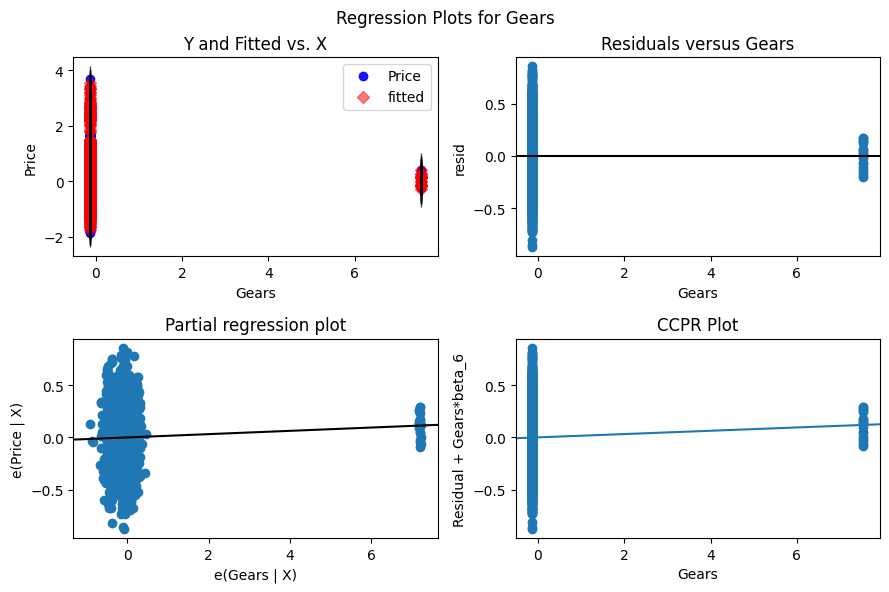

In [131]:
fig = plt.figure(figsize = (9,6))
sm.graphics.plot_regress_exog(model, 'Gears', fig=fig)
plt.show()

#### Observation: No Linear Relation found in QT Feature with the Dependent feature
### Model Testing

#### Observation: If the p-value is not less than .05 for Gears features, we fail to reject the null hypothesis. We do not have sufficient evidence to say that the sample data providing those features dependency towards the dependent variable
* Looking at the p-values, it looks like some of the variables aren't really significant (in the presence of other variables).


* We could simply drop the variable with the highest, non-significant p value. A better way would be to supplement this with the VIF information.

### Model Validation Techniques
* **Two Techniques 1) Collinearity Check - VIF   2) Residual Analysis**

### Calculating VIF ( Variance Inflation Factor )
* This helps to check the dependency among the features by building a model without the target and testing various combination among the features

#### Create a dataframe that will contain the names of all the feature variables and their respective VIFs

In [132]:
y = standard_scaled.drop(['Price'], axis=1)
vif = pd.DataFrame()
vif['Features'] = y.columns
vif['VIF'] = [variance_inflation_factor(y.values, i) for i in range(y.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
6,Weight,3.72
3,CC,3.20
0,Age,1.81
1,KM,1.56
2,HP,1.48
4,Doors,1.48
5,Gears,1.05


In [133]:
r_sqr_age = smf.ols('Age ~ HP+Weight+CC+Doors+Gears+KM', dataframe).fit().rsquared
vif_age = 1/(1-r_sqr_age)
r_sqr_weight = smf.ols('Weight ~ HP+Age+CC+Doors+Gears+KM', dataframe).fit().rsquared
vif_weight = 1/(1-r_sqr_weight)
r_sqr_cc = smf.ols('CC ~ HP+Weight+Age+Doors+Gears+KM', dataframe).fit().rsquared
vif_cc = 1/(1-r_sqr_cc)
r_sqr_hp = smf.ols('HP ~ Age+Weight+CC+Doors+Gears+KM', dataframe).fit().rsquared
vif_hp = 1/(1-r_sqr_hp)
r_sqr_km = smf.ols('KM ~ HP+Weight+CC+Doors+Gears+Age', dataframe).fit().rsquared
vif_km = 1/(1-r_sqr_km)
r_sqr_gears = smf.ols('Gears ~ HP+Weight+CC+Doors+Age+KM', dataframe).fit().rsquared
vif_gears = 1/(1-r_sqr_gears)
r_sqr_doors = smf.ols('Doors ~ HP+Weight+CC+Age+Gears+KM', dataframe).fit().rsquared
vif_doors = 1/(1-r_sqr_doors)

#### Storing vif values in a data frame

In [134]:
vif_frame = pd.DataFrame({'Variables':['Doors','HP','Weight','CC','Age','Gears','KM'], 'VIF':[vif_doors,vif_hp,vif_weight,vif_cc,vif_age,vif_gears,vif_km]}, index = None)
vif_frame.set_index('Variables', inplace = True)
vif_frame.sort_values(by = 'VIF')

,VIF
Variables,
Gears,1.049289
HP,1.475327
Doors,1.477872
KM,1.560874
Age,1.805482
CC,3.204858
Weight,3.721782


#### Note: We generally want a VIF that is less than 5. As you can see QT has the highest value among others lets investigate. We can say that there is no collinearity problem. So we shall consider all columns for building the model

### Residual Analysis
### Test for Normality of Residuals (Q-Q Plot)

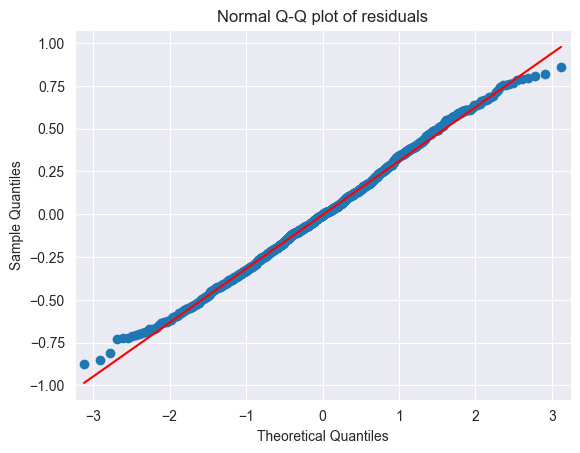

In [135]:
sns.set_style(style = 'darkgrid')
qqplot = sm.qqplot(model.resid,line='q') # line = 45 to draw the diagnoal line
plt.title("Normal Q-Q plot of residuals")
plt.show()

#### Significance level - Backward elimination
* We have different techniques to find out the features which have the maximum effect on the output.

* Here we are going to look at the Backward elimination.

* In this process we need to add one column of ones in the starting of the column.

* In backward elimination we delete the value one by one whose significance level is less.

* i.e In general we have a P-value and a significance level

* P_value = 1 - significane level

* or in other terms

* p_value + significance level = 1

* if P_value is high significance level is less.

* Hence we will be deleating features one by one whose P_value is high which means it has less significance level.

* By eliminating process we get to the values which are of most significance

#### Model1
* Dropping the variable and updating the model
* As you can see from the model and the VIF dataframe, some variables are still insignificant. One of these variables is, Gears as it has a very high P Value of 0.75 in SLR and 0.12 in MLR has R square score of 0. Let's go ahead and drop this variable

#### Dropping highly correlated variables and insignificant variables

In [136]:
x1 = standard_scaled.drop(['Gears'], axis=1)
y1 = standard_scaled.drop(['Gears','Price'], axis=1)

In [137]:
x1.columns

Index(['Price', 'Age', 'KM', 'HP', 'CC', 'Doors', 'Weight'], dtype='str')

In [140]:
model_1 = smf.ols('Price ~ Age+KM+HP+CC+Doors+Weight', data = x1).fit()
print('R-squared     :',model_1.rsquared.round(3))
print('Adj.R-squared :',model_1.rsquared_adj.round(3))
print('AIC Value     :',model_1.aic.round(3))
print('BIC Value     :',model_1.bic.round(3))
print('P-Value       :\n',model_1.pvalues)

R-squared     : 0.9
Adj.R-squared : 0.9
AIC Value     : 597.912
BIC Value     : 632.933
P-Value       :
 Intercept     1.000000e+00
Age          9.830845e-303
KM            1.525952e-43
HP            6.391136e-10
CC            1.287816e-22
Doors         1.915858e-05
Weight        6.476487e-91
dtype: float64


#### Observation: As our Multicollinearity problem has been solved
### Feature Selection Techniques in Machine Learning
### Correlation Coefficient
Correlation is a measure of the linear relationship of 2 or more variables. Through correlation, we can predict one variable from the other. The logic behind using correlation for feature selection is that the good variables are highly correlated with the target. Furthermore, variables should be correlated with the target but should be uncorrelated among themselves.

If two variables are correlated, we can predict one from the other. Therefore, if two features are correlated, the model only really needs one of them, as the second one does not add additional information. We will use the Pearson Correlation here.

In [141]:
toyota_corolla.corr()

,Price,Age,KM,HP,CC,Doors,Gears,Weight
Price,1.000000,-0.876273,-0.569420,0.314134,0.124375,0.183604,0.063831,0.575869
Age,-0.876273,1.000000,0.504575,-0.155293,-0.096549,-0.146929,-0.005629,-0.466484
KM,-0.569420,0.504575,1.000000,-0.332904,0.103822,-0.035193,0.014890,-0.023969
HP,0.314134,-0.155293,-0.332904,1.000000,0.035207,0.091803,0.209642,0.087143
CC,0.124375,-0.096549,0.103822,0.035207,1.000000,0.079254,0.014732,0.335077
Doors,0.183604,-0.146929,-0.035193,0.091803,0.079254,1.000000,-0.160101,0.301734
Gears,0.063831,-0.005629,0.014890,0.209642,0.014732,-0.160101,1.000000,0.021238
Weight,0.575869,-0.466484,-0.023969,0.087143,0.335077,0.301734,0.021238,1.000000


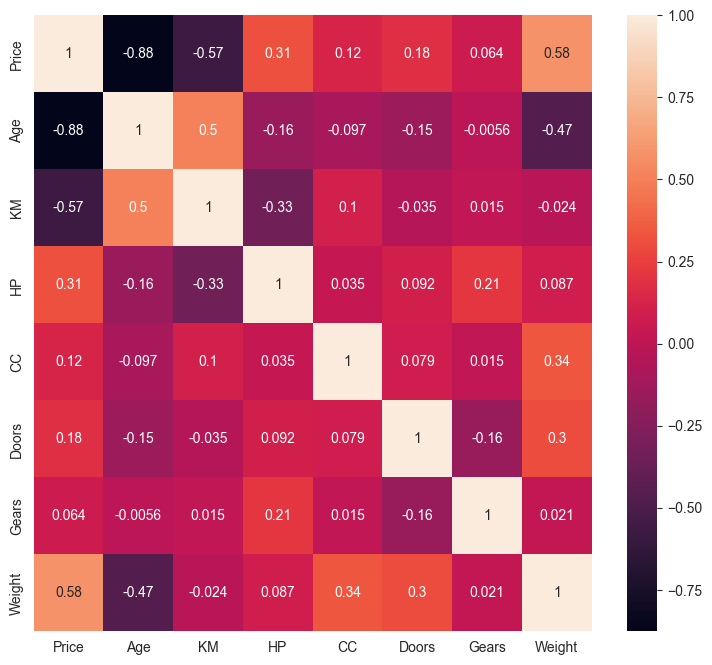

In [142]:
plt.figure(figsize=(9,8))
sns.heatmap(toyota_corolla.corr(),annot=True)
plt.show()

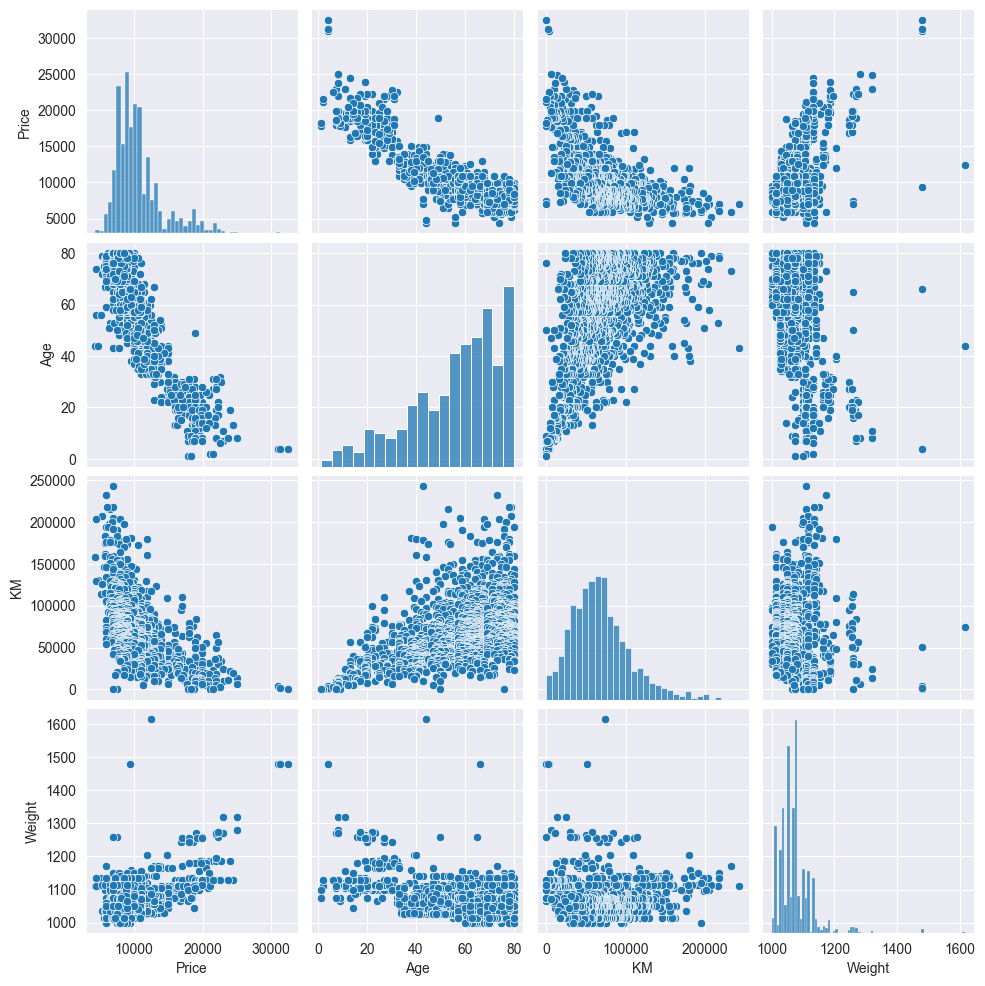

In [143]:
sns.set_style(style='darkgrid')
sns.pairplot(toyota_corolla[continuous_feature])
plt.show()

#### Observation: Age and KM has the highest score of correlation with Price but a negative correlation

* Note: QT and Weight also have a collinearity among themselves which will affect our model.
* Note: KM and Age also have a collinearity among themselves which will affect our model.

### PCA
Principal Component Analysis (PCA) was the first dimensionality reduction technique discovered (by Karl Pearson - yes, the guy from Pearson's correlation coefficient) and dates back to as early as 1901. It is very popular because it is fast, easy to implement and easy to interpret.

PCA works by finding a low dimensional subspace that maximises the variance of the data in that subspace and performing a linear projection. This basically means the data will be as spread out as possible, without changing the relationship between the data points. This allows us to find patterns or indentify clusters if any exist.

### PCA on Standard Scaled Dataset

Explained variance

Explained variance shows how much of the variance/spread of the data is captured in each dimension, i.e. how important each additional principal component is to the original data representation.

### Let's seperate the x and y values

In [144]:
standard_scaled.head()

,Price,Age,KM,HP,CC,Doors,Gears,Weight
0,2.106134,-2.154979,-0.653668,-1.071457,2.991969,-1.067094,-0.132576,3.131728
1,2.937572,-2.090576,0.881471,-1.071457,2.991969,-1.067094,-0.132576,5.510002
2,2.958891,-1.961770,-0.788534,0.717557,0.448667,-1.067094,-0.132576,3.280370
3,2.532512,-2.026173,-0.378699,0.717557,0.448667,-1.067094,-0.132576,1.793948
4,2.660426,-1.961770,-1.384384,0.717557,0.448667,-1.067094,-0.132576,1.793948


In [145]:
array = standard_scaled.values
x = array[:,1:]
y = array[:,1]

#### PCA

In [146]:
pca_var = PCA()
pca_var.fit(x)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

#### Plot

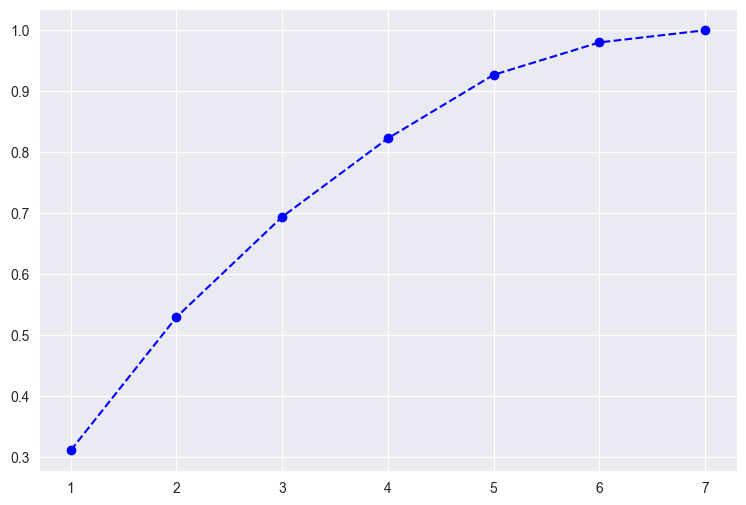

In [147]:
plt.figure(figsize=(9,6))
xi = np.arange(1, 1+x.shape[1], step=1)
yi = np.cumsum(pca_var.explained_variance_ratio_)
plt.plot(xi, yi, marker='o', linestyle='--', color='b')
plt.show()

#### Aesthetics

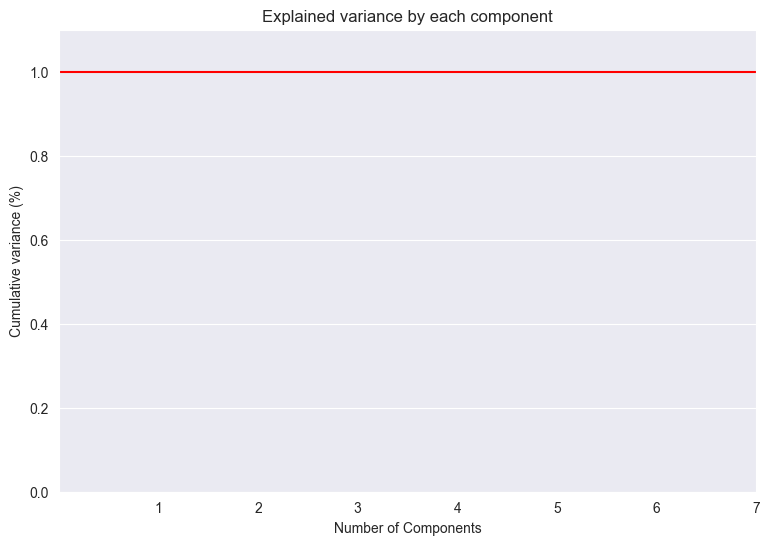

In [148]:
plt.figure(figsize=(9,6))
plt.ylim(0.0,1.1)
plt.xlabel('Number of Components')
plt.xticks(np.arange(1, 1+x.shape[1], step=1))
plt.ylabel('Cumulative variance (%)')
plt.title('Explained variance by each component')
plt.axhline(y=1, color='r', linestyle='-')
plt.gca().xaxis.grid(False)

#### The amount of variance that each PCA explains is 

In [149]:
var = pca_var.explained_variance_ratio_
var 

array([0.31029523, 0.2186984 , 0.1646092 , 0.12886892, 0.10429741,
       0.05326071, 0.01997013])

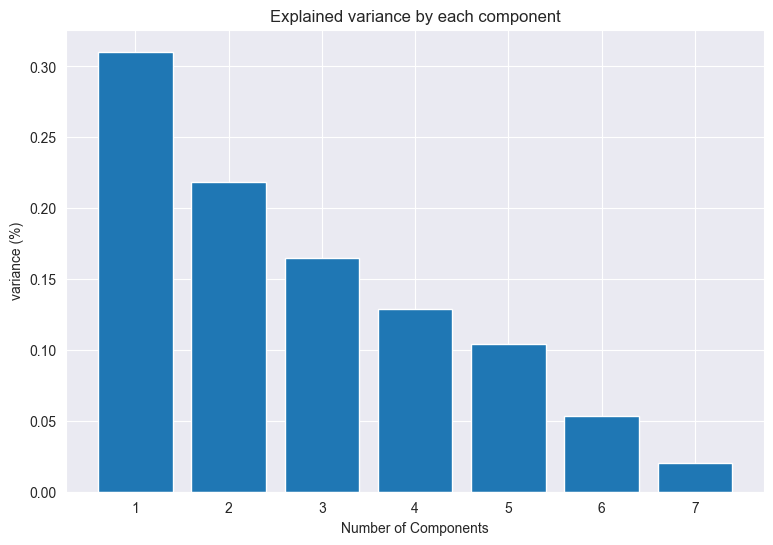

In [150]:
plt.figure(figsize=(9,6))
plt.bar(range(1, len(var)+1),var)
plt.xlabel('Number of Components')
plt.ylabel('variance (%)')
plt.title('Explained variance by each component')
plt.show()

#### Cumulative Variance

In [151]:
var1 = np.cumsum(np.round(var,decimals = 4)*100)
var1

array([ 31.03,  52.9 ,  69.36,  82.25,  92.68,  98.01, 100.01])

#### As you can see just by 5 feature we get a variance of more than 90%
#### PCA

In [152]:
pca = PCA()
pca_std = pca.fit_transform(x)

#### Convert to data frame

In [153]:
pca_std_df = pd.DataFrame(data = pca_std, columns = ['PC1', 'PC2','PC3','PC4', 'PC5','PC6','PC7','PC8'])

ValueError: Shape of passed values is (1100, 7), indices imply (1100, 8)

#### Shape and preview

In [ ]:
print(pca_std_df.shape)
pca_std_df.head()

In [ ]:
dataframe.Price

In [ ]:
pca_std_df['Price'] = y
pca_std_df.head()

In [ ]:
import statsmodels.formula.api as sm
pca_model = sm.ols('Price ~ PC1+PC2+PC3+PC4+PC5+PC6+PC7+PC8', data= pca_std_df).fit()
print('R-squared     :',pca_model.rsquared.round(3))
print('Adj.R-squared :',pca_model.rsquared_adj.round(3))
print('AIC Value     :',pca_model.aic.round(3))
print('BIC Value     :',pca_model.bic.round(3))

In [ ]:
transformer_y = StandardScaler().fit(dataframe['Price'].to_numpy().reshape(-1,1))
# Scale the test dataset
y_train_scal = transformer_y.transform(dataframe['Price'].to_numpy().reshape(-1,1))

# Predict with the trained model
predict = pd.DataFrame(pca_model.predict(pca_std_df))

# Inverse transform the prediction
predict_unscaled = transformer_y.inverse_transform(predict.values.reshape(-1,1))

# Predicting RMSE the Test set results
rmse_linear = (np.sqrt(mean_squared_error(dataframe.Price, predict_unscaled)))
print("R2_score          : ", pca_model.rsquared)
print("R2_Adjusted_score : ", pca_model.rsquared_adj)
print("RMSE              : ", rmse_linear)

In [ ]:
pca_std_df['Price'] = dataframe['Price']
pca_std_df.head()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(pca_std_df.iloc[:,:-1], pca_std_df.iloc[:,-1],test_size=0.3,random_state=10)
print("Shape of X_train : ",x_train.shape)
print("Shape of X_test  : ", x_test.shape)
print("Shape of y_train : ",y_train.shape)
print("Shape of y_test  : ",y_test.shape)

#### Scaling 

In [ ]:
transformer_x = StandardScaler().fit(x_train.to_numpy().reshape(-1,1))
transformer_y = StandardScaler().fit(y_train.to_numpy().reshape(-1,1)) 
x_train_scal = transformer_x.transform(y_train.to_numpy().reshape(-1,1))
x_test_scal = transformer_x.transform(y_test.to_numpy().reshape(-1,1))
y_train_scal = transformer_y.transform(y_train.to_numpy().reshape(-1,1))
y_test_scal = transformer_y.transform(y_test.to_numpy().reshape(-1,1))

#### Linear Regression

In [ ]:
regressor_linear = LinearRegression()
regressor_linear.fit(x_train, y_train_scal)

In [ ]:
lin_reg_model = LinearRegression().fit(x_train, y_train)
print(lin_reg_model.score(x_train, y_train),lin_reg_model.score(x_test, y_test))

In [ ]:
# Predict with the trained model
prediction = regressor_linear.predict(x_test)

# Inverse transform the prediction
prediction_unscaled = transformer_y.inverse_transform(prediction)

from sklearn.metrics import r2_score

# Predicting Cross Validation Score the Test set results
cv_linear = cross_val_score(estimator = regressor_linear, X = x_train, y = y_train_scal, cv = 10)

# Predicting R2 Score the Train set results
y_pred_linear_train = regressor_linear.predict(x_train)
r2_score_all_feature_train = r2_score(y_train_scal, y_pred_linear_train)

# Predicting R2 Score the Test set results
y_pred_linear_test = regressor_linear.predict(x_test)
r2_score_all_feature_test = r2_score(y_test_scal, y_pred_linear_test)

# Predicting RMSE the Test set results
rmse_linear_using_all_features = (np.sqrt(mean_squared_error(y_test, prediction_unscaled)))
print("CV                      : ", cv_linear.mean())
print("R2_score (train)        : ", r2_score_all_feature_train)
print("R2_score (test)         : ", r2_score_all_feature_test)
print("RMSE using all features : ", rmse_linear_using_all_features)

### Model Validation
**Comparing different models with respect to their Root Mean Squared Errors**

#### We will analyze Mean Squared Error (MSE) or Root Mean Squared Error (RMSE) — AKA the average distance (squared to get rid of negative numbers) between the model’s predicted target value and the actual target value.

In [154]:
x2 = dataframe[['Age','KM','HP','CC','Doors','Weight']]
y2 = dataframe[['Price']]
transformer_x = StandardScaler().fit(x2)
transformer_y = StandardScaler().fit(y2)
# Scale the test dataset
x_train_scal = transformer_x.transform(x2)
y_train_scal = transformer_y.transform(y2)

# Linear Regression
x_df = pd.DataFrame(x_train_scal, columns = ['Age','KM','HP','CC','Doors','Weight'])
x_df.head()

# Predict with the trained model
predict = pd.DataFrame(model_1.predict(x_df))

# Inverse transform the prediction
predict_unscaled = transformer_y.inverse_transform(predict.values.reshape(-1,1))

# Predicting RMSE the Test set results
rmse_linear= (np.sqrt(mean_squared_error(y2, predict_unscaled)))
print('R2_score          : ', model_1.rsquared)
print('R2_Adjusted_score : ', model_1.rsquared_adj)
print("RMSE              : ", rmse_linear)

R2_score          :  0.9004453079549566
R2_Adjusted_score :  0.8998988046134467
RMSE              :  740.0060632443024


In [155]:
square_root_pred_y =np.square(sqrt_transformed_model.predict(sqrt_scaled[['Age','Weight','KM','HP','CC','Doors','Gears']]))
cube_root_pred_y =pow(cbrt_transformed_model.predict(cbrt_scaled[['Age','Weight','KM','HP','CC','Doors','Gears']]),3)
log_model_pred_y =np.exp(log_transformed_model.predict(log_scaled[['Age','Weight','KM','HP','CC','Doors']]))


In [156]:
square_root_both_rmse =np.sqrt(mean_squared_error(dataframe['Price'], square_root_pred_y))
cube_root_both_rmse =np.sqrt(mean_squared_error(dataframe['Price'], cube_root_pred_y))
log_both_rmse =np.sqrt(mean_squared_error(dataframe['Price'], log_model_pred_y))

In [157]:
print    ('Raw Model                                     :', np.sqrt(raw_data_model.mse_resid),
      '\n''After Removing Influencers                    :', np.sqrt(final_model.mse_resid),
      '\n''After Log Transformation on both Model        :', log_both_rmse,
      '\n''After Cube-root Transformation on both Model  :', cube_root_both_rmse,
      '\n''After Sqaure Root Transformation on both Model:', square_root_both_rmse,
      '\n''After Removing Influencers from model         :', np.sqrt(final_model.mse_resid),
      '\n''Final Model without Multicollinearity Model   :', rmse_linear)

Raw Model                                     : 743.2103166639253 
After Removing Influencers                    : 741.8234077003348 
After Log Transformation on both Model        : 1778.525084087763 
After Cube-root Transformation on both Model  : 947.9249094280939 
After Sqaure Root Transformation on both Model: 817.8369128965902 
After Removing Influencers from model         : 741.8234077003348 
Final Model without Multicollinearity Model   : 740.0060632443024


### Let's compare the Root Mean Squared Error and check for the minimum value

In [158]:
rmse_compare = {'Raw Model': np.sqrt(raw_data_model.mse_resid),
                'After Removing Influencers': np.sqrt(final_model.mse_resid),
                'After Log Transformation Model': log_both_rmse,
                'After Cube-root Transformation Model': cube_root_both_rmse,
                'After Sqaure Root Transformation Model': square_root_both_rmse,
                'After Removing Influencers from model': np.sqrt(final_model.mse_resid),
                'Final Model without Multicollinearity Model': rmse_linear}
min(rmse_compare, key=rmse_compare.get)

'Final Model without Multicollinearity Model'

#### Observation: The Model that was build without Multicollinearity Issue and using Standard Scaler Transformation performed very well.
* Scoring minimumn Root mean squared error and a good R-squared and adjusted R-squared
* Note: We are going to rebuild the model by using that model

In [ ]:
x1.columns

In [159]:
final_model = smf.ols("Price ~ Age+KM+HP+CC+Doors+Weight", data = x1).fit()
# Finding rsquared values
print('R-squared     :',final_model.rsquared.round(3))
print('Adj.R-squared :',final_model.rsquared_adj.round(3))
print('AIC Value     :',final_model.aic.round(3))
print('BIC Value     :',final_model.bic.round(3))

R-squared     : 0.9
Adj.R-squared : 0.9
AIC Value     : 597.912
BIC Value     : 632.933


### Residual Analysis
* Test for Normality of Residuals (Q-Q Plot)

### Residuals values  = y - yhat

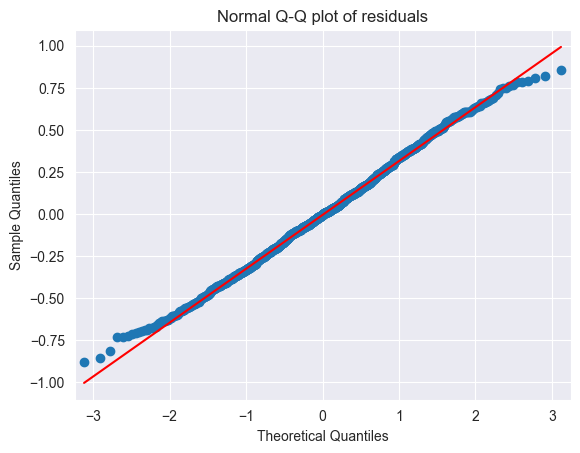

In [160]:
import statsmodels.api as sm
sm.qqplot(final_model.resid, line = 'q')
plt.title('Normal Q-Q plot of residuals')
plt.show()

#### Observation: Error should have Normal / Gaussian distribution~N(0,1) and idenpendently and identically distributed.
### Residual Plot for Homoscedasticity

In [161]:
def get_standardized_values( vals ):
    return (vals - vals.mean())/vals.std()

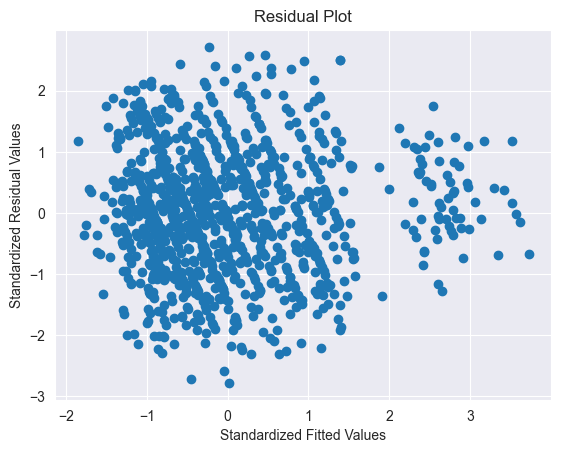

In [162]:
plt.scatter(get_standardized_values(final_model.fittedvalues), get_standardized_values(final_model.resid))
plt.title('Residual Plot')
plt.xlabel('Standardized Fitted Values')
plt.ylabel('Standardized Residual Values')
plt.show()

#### Observation: Constant Variance (Homoscedasticity) in Error
### Residual VS Regressors
* Plotting to visualize the partial relation of each independent feature with the Dependent variable and errors

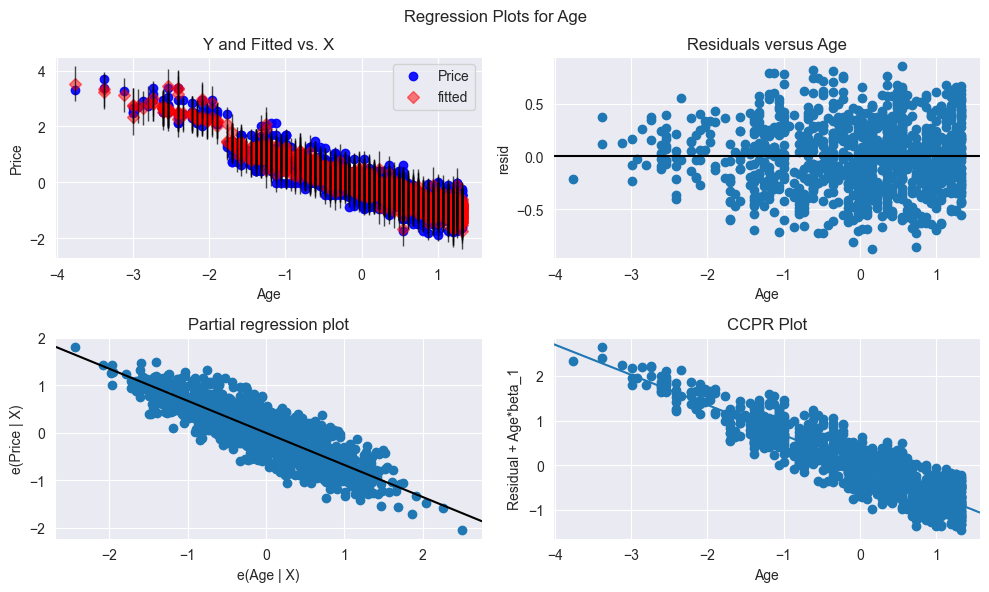

In [163]:
fig = plt.figure(figsize = (10,6))
sm.graphics.plot_regress_exog(final_model, 'Age', fig=fig)
plt.show()

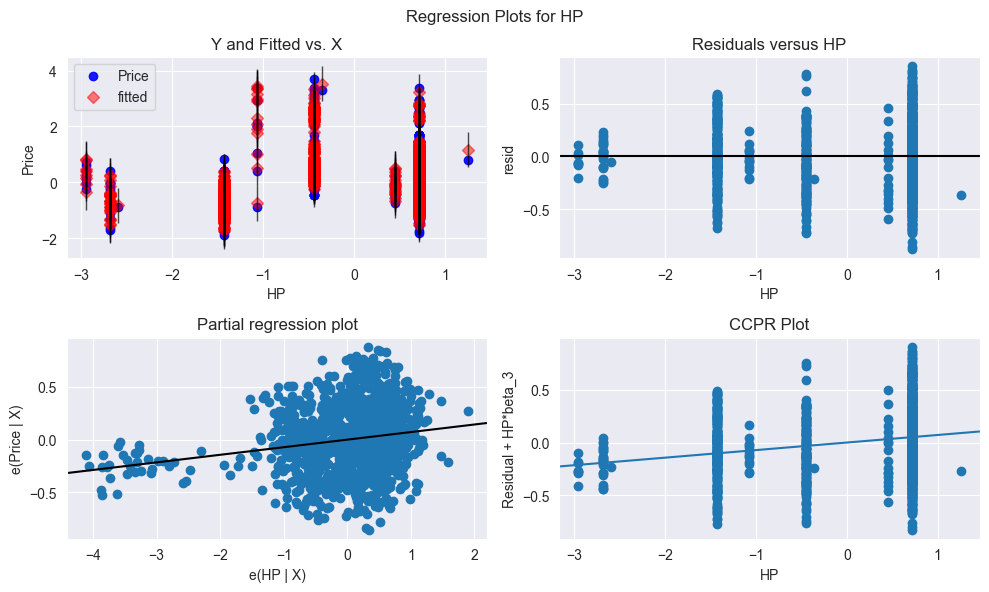

In [164]:
fig = plt.figure(figsize = (10,6))
sm.graphics.plot_regress_exog(final_model, 'HP', fig=fig)
plt.show()

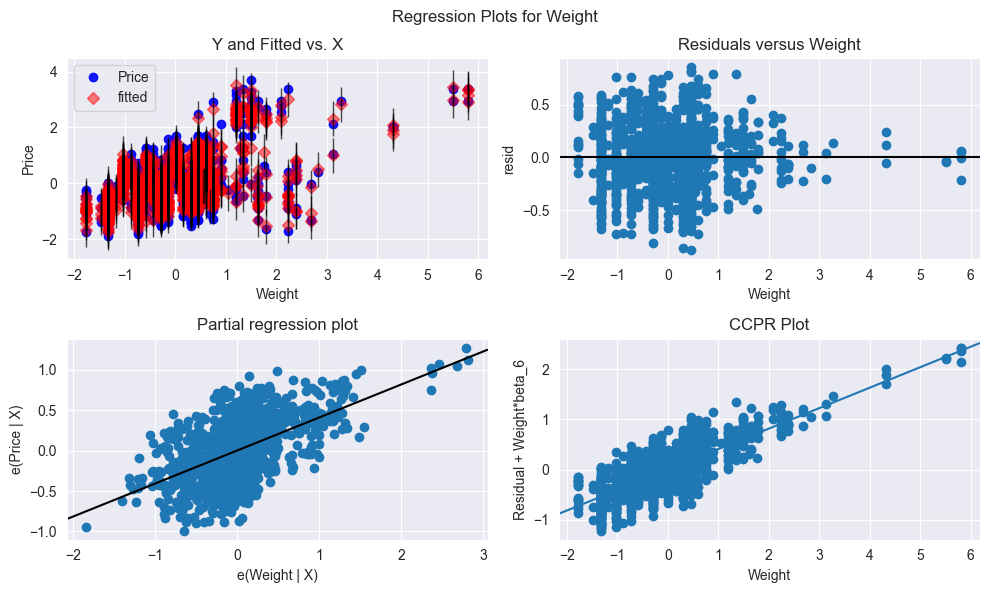

In [165]:
fig = plt.figure(figsize = (10,6))
sm.graphics.plot_regress_exog(final_model, 'Weight', fig=fig)
plt.show()

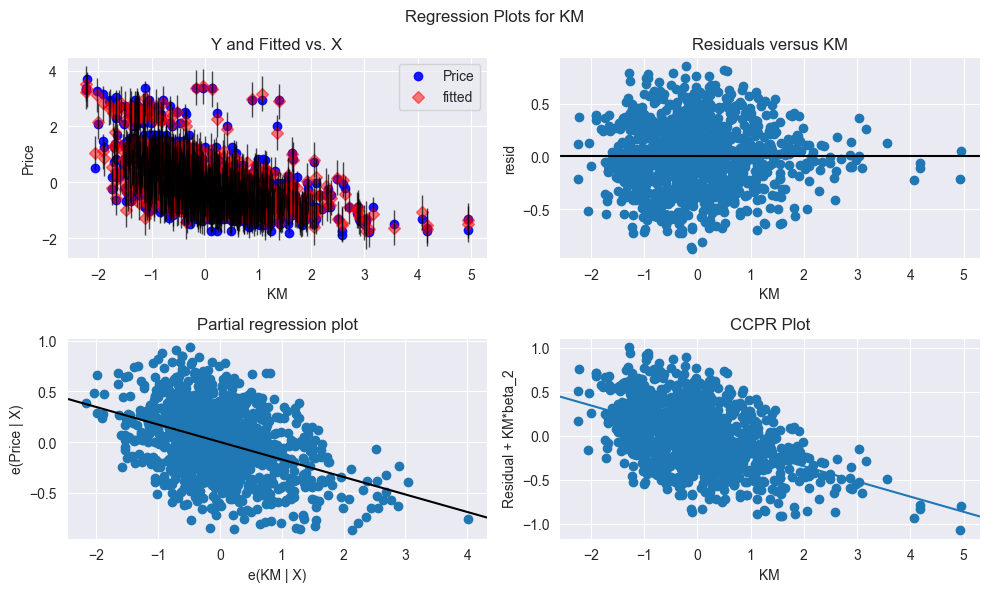

In [166]:
fig = plt.figure(figsize = (10,6))
sm.graphics.plot_regress_exog(final_model, 'KM', fig=fig)
plt.show()

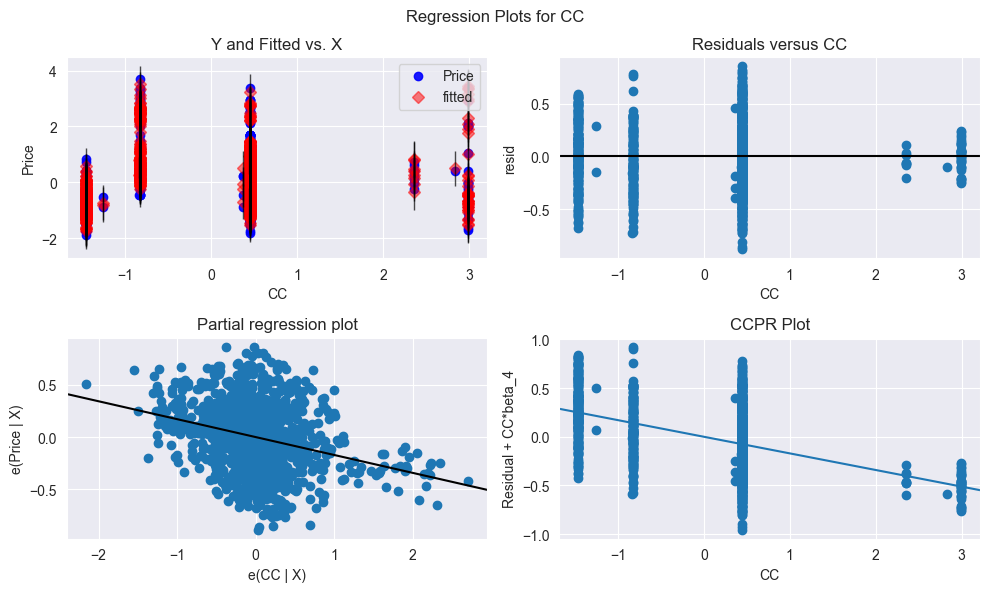

In [167]:
fig = plt.figure(figsize = (10,6))
sm.graphics.plot_regress_exog(final_model, 'CC', fig=fig)
plt.show()

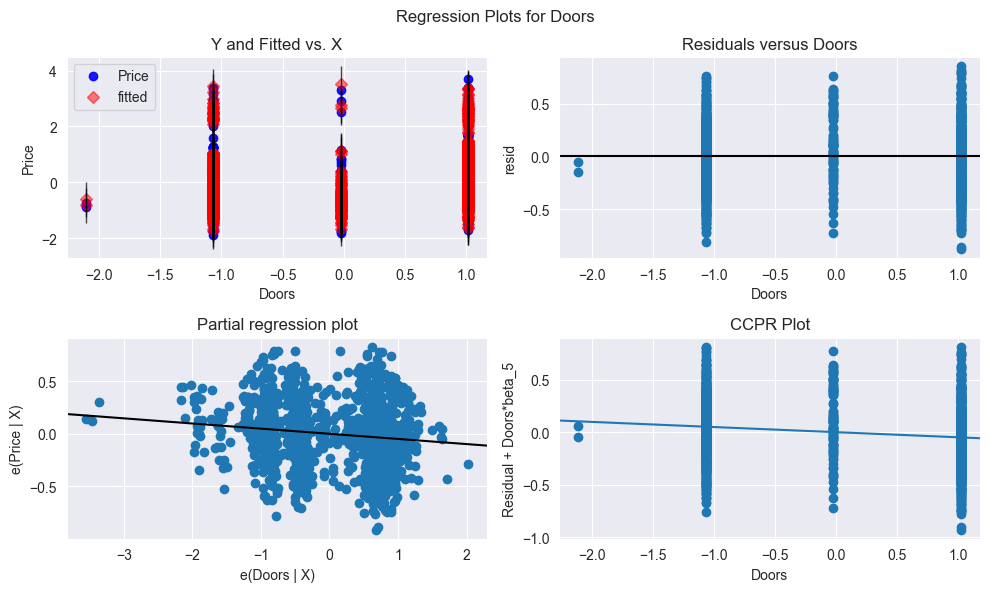

In [168]:
fig = plt.figure(figsize = (10,6))
sm.graphics.plot_regress_exog(final_model, 'Doors', fig=fig)
plt.show()

#### Observation:
* Some of the feature doesn't suggest linear relationship with the Dependent feature like Gears, QT, CC, Doors, Weight and HP
* Only KM and Age is having a linear relation with the Price Feature

### Predicting values from Model using same dataset

In [169]:
x = dataframe[['Age','KM','HP','CC','Doors','Weight']]
y = dataframe[['Price']]
transformer_x = StandardScaler().fit(x)
transformer_y = StandardScaler().fit(y)
# Scale the test dataset
x_train_scal = transformer_x.transform(x)
y_train_scal = transformer_y.transform(y)

# Linear Regression
x_df = pd.DataFrame(x_train_scal, columns = ['Age','KM','HP','CC','Doors','Weight'])
x_df.head()

# Predict with the trained model
predict = pd.DataFrame(final_model.predict(x_df))

# Inverse transform the prediction
predict_unscaled = transformer_y.inverse_transform(predict.values.reshape(-1,1))
predict_unscaled

array([[15426.43600578],
       [16978.5279952 ],
       [16637.24428671],
       ...,
       [ 9082.94494293],
       [ 7709.71765712],
       [ 8707.17864341]], shape=(1100, 1))

In [170]:
(np.sqrt(mean_squared_error(y, predict_unscaled)))

np.float64(740.0060632443024)

In [171]:
predicted = pd.DataFrame(predict_unscaled,columns=['Predicted_Price'])
predicted['Price'] = dataframe.Price
predicted['Age'] = dataframe.Age
predicted['KM'] = dataframe.KM
predicted['Weight'] = dataframe.Weight
predicted['HP'] = dataframe.HP
predicted['CC'] = dataframe.CC
predicted['Doors'] = dataframe.Doors
predicted

,Predicted_Price,Price,Age,KM,Weight,HP,CC,Doors
0,15426.436006,14950,26,48000,1165,90,2000,3
1,16978.527995,16900,27,94612,1245,90,2000,3
2,16637.244287,16950,29,43905,1170,110,1600,3
3,15151.401217,15950,28,56349,1120,110,1600,3
4,15456.336910,16250,29,25813,1120,110,1600,3
...,...,...,...,...,...,...,...,...
1095,9400.681345,8950,71,29000,1045,86,1300,3
1096,8485.494064,8450,72,26000,1015,86,1300,3
1097,9082.944943,8950,78,24000,1065,86,1300,5
1098,7709.717657,8450,80,23000,1015,86,1300,3


### Preparing a table containing R square  value for each prepared model

In [172]:
models={'Different_Models':['Raw_Data_Model','After_Removing_Outlier_Model','After_Log Transformation_Model','After_Cube-Root_Transformation_Model','After_Sqaure_Root_Transformation_Model','Final_Model_Without_Multicollinearity_Model'],
        'R_squared':[raw_data_model.rsquared,final_model.rsquared,log_transformed_model.rsquared,cbrt_transformed_model.rsquared,sqrt_transformed_model.rsquared,model_1.rsquared],
        'R_squared_adjusted':[raw_data_model.rsquared_adj,final_model.rsquared_adj,log_transformed_model.rsquared_adj,cbrt_transformed_model.rsquared_adj,sqrt_transformed_model.rsquared_adj,model_1.rsquared_adj],
        'RMSE':[np.sqrt(raw_data_model.mse_resid),np.sqrt(final_model.mse_resid),log_both_rmse,cube_root_both_rmse,square_root_both_rmse,rmse_linear]}
model_table = pd.DataFrame(models)
model_table

,Different_Models,R_squared,R_squared_adjusted,RMSE
0,Raw_Data_Model,0.900239,0.899600,743.210317
1,After_Removing_Outlier_Model,0.900445,0.899899,0.316532
2,After_Log Transformation_Model,0.746473,0.745081,1778.525084
3,After_Cube-Root_Transformation_Model,0.846878,0.845896,947.924909
4,After_Sqaure_Root_Transformation_Model,0.872065,0.871245,817.836913
5,Final_Model_Without_Multicollinearity_Model,0.900445,0.899899,740.006063


### Visualizing Models Performance

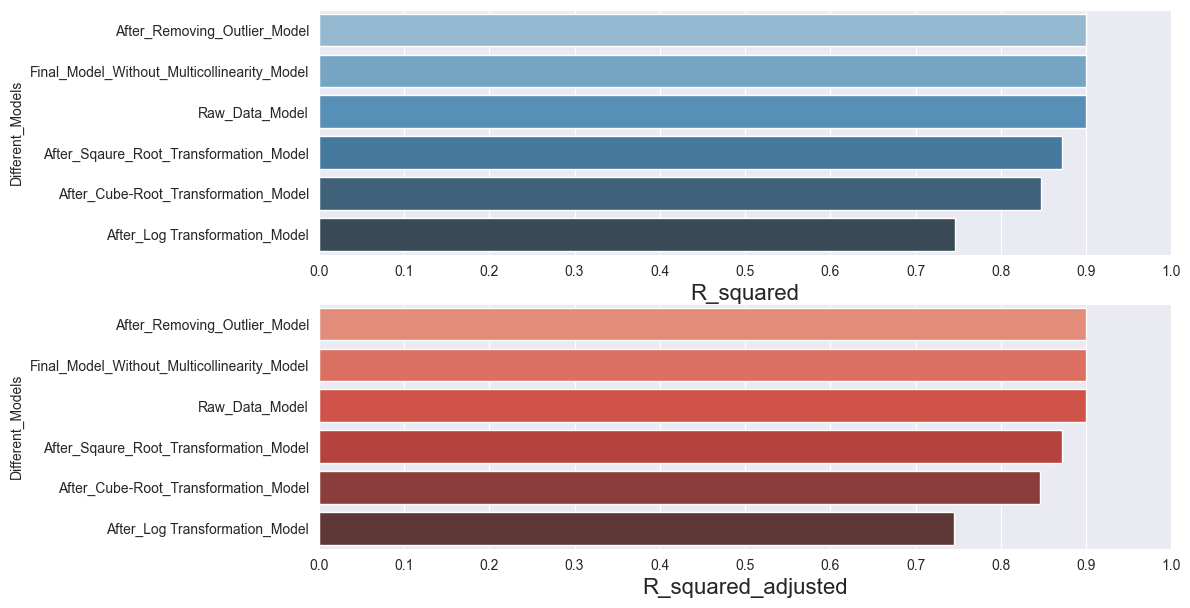

In [173]:
f, axes = plt.subplots(2,1, figsize=(11,7))

model_table.sort_values(by=['R_squared'], ascending=False, inplace=True)

sns.barplot(x='R_squared', y='Different_Models', data = model_table, palette='Blues_d', ax = axes[0])
axes[0].set_xlabel('R_squared', size=16)
axes[0].set_ylabel('Different_Models')
axes[0].set_xlim(0,1.0)
axes[0].set_xticks(np.arange(0, 1.1, 0.1))

model_table.sort_values(by=['R_squared_adjusted'], ascending=False, inplace=True)

sns.barplot(x='R_squared_adjusted', y='Different_Models', data = model_table, palette='Reds_d', ax = axes[1])
axes[1].set_xlabel('R_squared_adjusted', size=16)
axes[1].set_ylabel('Different_Models')
axes[1].set_xlim(0,1.0)
axes[1].set_xticks(np.arange(0, 1.1, 0.1))

plt.show()

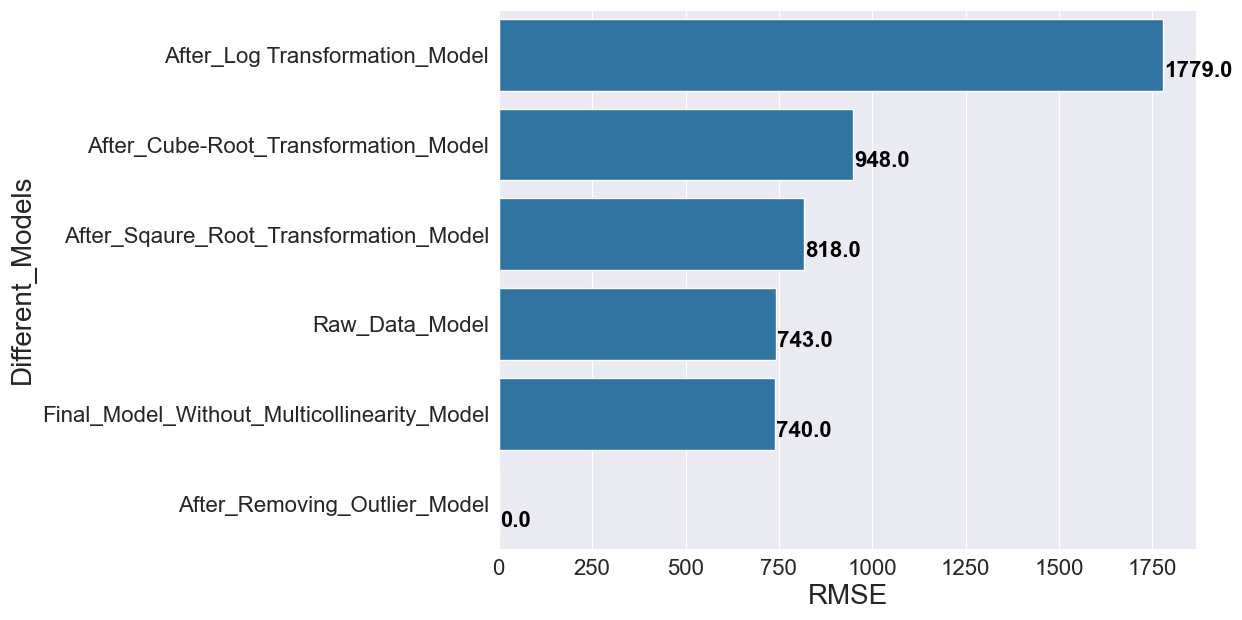

In [174]:
model_table.sort_values(by=['RMSE'], ascending=False, inplace=True)

f, axe = plt.subplots(1,1, figsize=(9,7))
sns.barplot(x='RMSE', y='Different_Models', data=model_table, ax = axe)
axe.set_xlabel('RMSE', size=20)
axe.set_ylabel('Different_Models', size=20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

for i, v in enumerate(np.round(model_table.RMSE.values,0)):
    axe.text(v + 3, i + .25, str(v),
    color = 'black', fontweight = 'bold', fontsize= 16)
plt.show()

### Conclusion:
* R² Score: 0.90
* Adjusted R²: 0.899
* RMSE: 740
* Final Model Accuracy: ~90%

* Most Important Variables Affecting Price Based on p-values & coefficients:
  * Strong Impact Variables
Age → Strong negative impact (older cars cheaper)
KM → Strong negative impact (more driven cheaper)
Weight → Strong positive impact (heavier cars cost more)
HP → Positive impact
CC → Moderate positive impact
  * Weak / Less Important Variables
Doors → Very small impact
Gears → Not significant (high p-value)

* Final Important Features:
Age, KM, Weight, HP, CC